In [1]:
from pathlib import Path
import pandas as pd

OUTPUT_DIR = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output")

PART_FILES = sorted(OUTPUT_DIR.glob("01_user_park_big_table_part_*.csv"))
SINGLE_FILE = OUTPUT_DIR / "01_user_park_big_table.csv"

wanted_cols = [
    "user_ID", "osm_id", "park_name", "visit_count",
    "home_Lng", "home_Lat",
    "park_centroid_lng", "park_centroid_lat",
    "target_lng", "target_lat",
    "target_type", "target_source",
    "straight_distance_m"
]

if len(PART_FILES) > 0:
    print("发现拆分文件，开始合并读取...")
    dfs = []
    for f in PART_FILES:
        tmp = pd.read_csv(f, usecols=lambda c: c in wanted_cols)
        dfs.append(tmp)
    df = pd.concat(dfs, ignore_index=True)
elif SINGLE_FILE.exists():
    print("发现单文件，开始读取...")
    df = pd.read_csv(SINGLE_FILE, usecols=lambda c: c in wanted_cols)
else:
    raise FileNotFoundError("没有找到大表文件或拆分文件。")

df = df.dropna(subset=["home_Lng", "home_Lat", "target_lng", "target_lat"]).copy()

print("df 读取完成")
print("行数:", len(df))
display(df.head())

发现拆分文件，开始合并读取...
df 读取完成
行数: 3194986


,user_ID,osm_id,park_name,visit_count,home_Lng,home_Lat,park_centroid_lng,park_centroid_lat,target_lng,target_lat,target_type,target_source,straight_distance_m
0,00000164e18db30860b01aa1990e0a9c,70364651,横浜公園,3,139.447286,35.538822,139.640246,35.443720,139.638382,35.443114,nearest_boundary_point,polygon_boundary_fallback,20312.077568
1,000003258065e75aecfeb4adcc239ccc,176606767,神明都電車庫跡公園,1,139.554684,35.701662,139.755092,35.732976,139.754915,35.732773,nearest_boundary_point,polygon_boundary_fallback,18404.895326
2,000003258065e75aecfeb4adcc239ccc,659219165,礫川公園,1,139.554684,35.701662,139.751091,35.707925,139.750507,35.707934,nearest_boundary_point,polygon_boundary_fallback,17695.409043
3,000003258065e75aecfeb4adcc239ccc,691546714,教育の森公園,1,139.554684,35.701662,139.736098,35.719939,139.734909,35.720260,nearest_boundary_point,polygon_boundary_fallback,16402.847881
4,00000aad2d0d8c9deac6672f2e52f6a8,835951188,越谷総合公園,2,139.569699,36.127787,139.815957,35.902556,139.813795,35.904619,nearest_boundary_point,polygon_boundary_fallback,33132.609098


In [2]:
home_points = pd.read_csv(OUTPUT_DIR / "home_points_with_nodes.csv")
target_points = pd.read_csv(OUTPUT_DIR / "target_points_with_nodes.csv")

print("home_points 行数:", len(home_points))
print("target_points 行数:", len(target_points))

display(home_points.head())
display(target_points.head())

home_points 行数: 1232352
target_points 行数: 228955


,user_ID,home_Lng,home_Lat,home_node
0,00000164e18db30860b01aa1990e0a9c,139.447286,35.538822,582882074
1,000003258065e75aecfeb4adcc239ccc,139.554684,35.701662,556604651
2,00000aad2d0d8c9deac6672f2e52f6a8,139.569699,36.127787,1349049769
3,0000230787c46d45a490ef27f4cacd7b,139.921506,35.887192,6563006113
4,0000280074bce411e22ef5770ed2cc7d,139.554410,35.558002,7351627437


,osm_id,target_lng,target_lat,target_node
0,70364651,139.638382,35.443114,3125512141
1,176606767,139.754915,35.732773,5615038164
2,659219165,139.750507,35.707934,5789957196
3,691546714,139.734909,35.720260,2104007830
4,835951188,139.813795,35.904619,8415045017


In [4]:
# ===== 用 map 回填节点：home 用 user_ID，target 用“osm_id+target坐标”联合键 =====
import pandas as pd
import numpy as np

# 先尽量瘦身，只保留后续需要的列
keep_cols = [
    "user_ID", "osm_id", "park_name", "visit_count",
    "home_Lng", "home_Lat",
    "park_centroid_lng", "park_centroid_lat",
    "target_lng", "target_lat",
    "target_type", "target_source",
    "straight_distance_m"
]
keep_cols = [c for c in keep_cols if c in df.columns]
df = df[keep_cols].copy()

# 统一类型
df["user_ID"] = df["user_ID"].astype(str)
df["osm_id"] = df["osm_id"].astype(str)

home_points["user_ID"] = home_points["user_ID"].astype(str)
target_points["osm_id"] = target_points["osm_id"].astype(str)

# ===== 构造 target_key：osm_id + target_lng + target_lat =====
# 为避免浮点误差，先统一保留 6 位小数
df["target_lng_r"] = df["target_lng"].round(6)
df["target_lat_r"] = df["target_lat"].round(6)

target_points["target_lng_r"] = target_points["target_lng"].round(6)
target_points["target_lat_r"] = target_points["target_lat"].round(6)

df["target_key"] = (
    df["osm_id"] + "||" +
    df["target_lng_r"].astype(str) + "||" +
    df["target_lat_r"].astype(str)
)

target_points["target_key"] = (
    target_points["osm_id"] + "||" +
    target_points["target_lng_r"].astype(str) + "||" +
    target_points["target_lat_r"].astype(str)
)

# ===== 建立映射 =====
# home: 一个 user_ID 只有一个 home_node
home_map = (
    home_points.drop_duplicates(subset=["user_ID"])
    .set_index("user_ID")["home_node"]
)

# target: 用 target_key 做唯一映射，不再用 osm_id
target_map = (
    target_points.drop_duplicates(subset=["target_key"])
    .set_index("target_key")["target_node"]
)

# ===== 回填 =====
df["home_node"] = df["user_ID"].map(home_map)
df["target_node"] = df["target_key"].map(target_map)

print("回填完成")
print("行数:", len(df))
print("缺失 home_node:", df["home_node"].isna().sum())
print("缺失 target_node:", df["target_node"].isna().sum())

print("target_points 中重复 osm_id 数量:", target_points["osm_id"].duplicated().sum())
print("target_points 中重复 target_key 数量:", target_points["target_key"].duplicated().sum())

display(df[[
    "user_ID", "osm_id", "visit_count",
    "home_Lng", "home_Lat",
    "target_lng", "target_lat",
    "home_node", "target_node"
]].head())

回填完成
行数: 3194986
缺失 home_node: 0
缺失 target_node: 0
target_points 中重复 osm_id 数量: 222990
target_points 中重复 target_key 数量: 3544


,user_ID,osm_id,visit_count,home_Lng,home_Lat,target_lng,target_lat,home_node,target_node
0,00000164e18db30860b01aa1990e0a9c,70364651,3,139.447286,35.538822,139.638382,35.443114,582882074,3125512141
1,000003258065e75aecfeb4adcc239ccc,176606767,1,139.554684,35.701662,139.754915,35.732773,556604651,5615038164
2,000003258065e75aecfeb4adcc239ccc,659219165,1,139.554684,35.701662,139.750507,35.707934,556604651,5789957196
3,000003258065e75aecfeb4adcc239ccc,691546714,1,139.554684,35.701662,139.734909,35.720260,556604651,2104007830
4,00000aad2d0d8c9deac6672f2e52f6a8,835951188,2,139.569699,36.127787,139.813795,35.904619,1349049769,8415045017


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd

CUTOFF_M = 10000   # 先只算 10 km 内的精确路网距离
PAIR_FILE = OUTPUT_DIR / "node_pairs_for_network_distance.csv"

# 只保留后面真正要用的列
pair_base = df[[
    "home_node",
    "target_node",
    "straight_distance_m"
]].copy()

# 同一个 home_node + target_node 只算一次
pair_df = (
    pair_base
    .groupby(["home_node", "target_node"], as_index=False)["straight_distance_m"]
    .min()
)

print("唯一 node pair 数量:", len(pair_df))

# 直线距离先筛一轮
pair_df["pair_status"] = np.where(
    pair_df["straight_distance_m"] <= CUTOFF_M,
    "to_compute",
    "beyond_cutoff"
)

print(pair_df["pair_status"].value_counts())

pair_df.to_csv(PAIR_FILE, index=False, encoding="utf-8-sig")
print("已保存:", PAIR_FILE)

display(pair_df.head())

唯一 node pair 数量: 2547514
pair_status
to_compute       1518534
beyond_cutoff    1028980
Name: count, dtype: int64
已保存: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/node_pairs_for_network_distance.csv


,home_node,target_node,straight_distance_m,pair_status
0,31236738,6187723980,5138.228250,to_compute
1,31236738,9933529996,32384.971901,beyond_cutoff
2,31236738,11348392014,10408.416170,beyond_cutoff
3,31236739,277492152,30200.329780,beyond_cutoff
4,31236739,305880272,29796.602903,beyond_cutoff


In [6]:
import pandas as pd
import numpy as np
import networkx as nx
import osmnx as ox
from pathlib import Path

# ===== 参数 =====
CUTOFF_M = 10000
TARGET_BATCH_SIZE = 20   # 每批处理 20 个 target_node，先稳一点

OUTPUT_DIR = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output")
PAIR_FILE = OUTPUT_DIR / "node_pairs_for_network_distance.csv"
GRAPHML_FILE = OUTPUT_DIR / "walk_network_from_research_area.graphml"
BATCH_DIR = OUTPUT_DIR / "network_distance_batches"
BATCH_DIR.mkdir(parents=True, exist_ok=True)

# ===== 如果当前内存里没有 Gp，就从缓存路网重建 =====
if "Gp" not in globals():
    print("内存中没有 Gp，开始从 graphml 重建投影路网...")
    G = ox.load_graphml(GRAPHML_FILE)
    G = ox.distance.add_edge_lengths(G)
    Gu = ox.convert.to_undirected(G)
    Gp = ox.project_graph(Gu)
    print("Gp 重建完成")

# ===== 读取 pair 文件 =====
pair_df = pd.read_csv(PAIR_FILE)

pair_compute = pair_df[pair_df["pair_status"] == "to_compute"][["home_node", "target_node"]].copy()
pair_compute["home_node"] = pair_compute["home_node"].astype("int64")
pair_compute["target_node"] = pair_compute["target_node"].astype("int64")

print("需要精确计算的 pair 数量:", len(pair_compute))

# ===== 先按 target_node 分组 =====
grouped = pair_compute.groupby("target_node")
target_nodes_list = sorted(grouped.groups.keys())

print("需要计算的唯一 target_node 数量:", len(target_nodes_list))

# ===== 分批处理 =====
for batch_index, start in enumerate(range(0, len(target_nodes_list), TARGET_BATCH_SIZE), start=1):
    end = min(start + TARGET_BATCH_SIZE, len(target_nodes_list))
    batch_targets = target_nodes_list[start:end]

    batch_file = BATCH_DIR / f"network_distance_batch_{batch_index:04d}.csv"
    if batch_file.exists():
        print("已存在，跳过:", batch_file.name)
        continue

    print(f"开始处理 batch {batch_index}: target_node 第 {start} 到 {end} 个...")

    rows = []

    for target_node in batch_targets:
        grp = grouped.get_group(target_node)
        needed_home_nodes = grp["home_node"].tolist()

        lengths = nx.single_source_dijkstra_path_length(
            Gp,
            source=int(target_node),
            cutoff=CUTOFF_M,
            weight="length"
        )

        for home_node in needed_home_nodes:
            rows.append({
                "home_node": int(home_node),
                "target_node": int(target_node),
                "network_distance_m": lengths.get(int(home_node), np.nan)
            })

    batch_df = pd.DataFrame(rows)
    batch_df.to_csv(batch_file, index=False, encoding="utf-8-sig")
    print("已保存:", batch_file.name, "行数:", len(batch_df))

print("所有 batch 处理完成")

内存中没有 Gp，开始从 graphml 重建投影路网...
Gp 重建完成
需要精确计算的 pair 数量: 1518534
需要计算的唯一 target_node 数量: 41377
开始处理 batch 1: target_node 第 0 到 20 个...
已保存: network_distance_batch_0001.csv 行数: 1550
开始处理 batch 2: target_node 第 20 到 40 个...
已保存: network_distance_batch_0002.csv 行数: 1347
开始处理 batch 3: target_node 第 40 到 60 个...
已保存: network_distance_batch_0003.csv 行数: 1496
开始处理 batch 4: target_node 第 60 到 80 个...
已保存: network_distance_batch_0004.csv 行数: 784
开始处理 batch 5: target_node 第 80 到 100 个...
已保存: network_distance_batch_0005.csv 行数: 251
开始处理 batch 6: target_node 第 100 到 120 个...
已保存: network_distance_batch_0006.csv 行数: 470
开始处理 batch 7: target_node 第 120 到 140 个...
已保存: network_distance_batch_0007.csv 行数: 389
开始处理 batch 8: target_node 第 140 到 160 个...
已保存: network_distance_batch_0008.csv 行数: 737
开始处理 batch 9: target_node 第 160 到 180 个...
已保存: network_distance_batch_0009.csv 行数: 477
开始处理 batch 10: target_node 第 180 到 200 个...
已保存: network_distance_batch_0010.csv 行数: 909
开始处理 batch 11: target_node 第 200

In [10]:
from pathlib import Path

OUTPUT_DIR = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output")
BATCH_DIR = OUTPUT_DIR / "network_distance_batches"

batch_files = sorted(BATCH_DIR.glob("network_distance_batch_*.csv"))
print("准备删除 batch 文件数:", len(batch_files))

for f in batch_files:
    f.unlink()

print("删除完成")
print("剩余 batch 文件数:", len(list(BATCH_DIR.glob('network_distance_batch_*.csv'))))

准备删除 batch 文件数: 2069
删除完成
剩余 batch 文件数: 0


In [11]:
import osmnx as ox

GRAPHML_FILE = OUTPUT_DIR / "walk_network_from_research_area.graphml"

print("开始读取缓存路网...")
G = ox.load_graphml(GRAPHML_FILE)
print("原始路网:", G)

G = ox.distance.add_edge_lengths(G)

# 先投影
Gp = ox.project_graph(G)
print("投影后图:", Gp)

# 再转无向 —— 这一句最关键
Gpu = ox.convert.to_undirected(Gp)
print("最终用于最短路的无向图:", Gpu)

开始读取缓存路网...
原始路网: MultiDiGraph with 1448374 nodes and 4170958 edges
投影后图: MultiDiGraph with 1448374 nodes and 4170958 edges
最终用于最短路的无向图: MultiGraph with 1448374 nodes and 2085478 edges


In [16]:
import pandas as pd
import numpy as np
import networkx as nx
import osmnx as ox
from pathlib import Path

OUTPUT_DIR = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output")
PAIR_FILE = OUTPUT_DIR / "node_pairs_for_network_distance.csv"
GRAPHML_FILE = OUTPUT_DIR / "walk_network_from_research_area.graphml"
BATCH_DIR = OUTPUT_DIR / "network_distance_batches"
BATCH_DIR.mkdir(parents=True, exist_ok=True)

# ===== 参数 =====
CUTOFF_M = 15000
TARGET_BATCH_SIZE = 20

# ===== 如果当前内存里没有 Gpu，就自动重建 =====
if "Gpu" not in globals():
    print("内存中没有 Gpu，开始从 graphml 重建...")
    G = ox.load_graphml(GRAPHML_FILE)
    G = ox.distance.add_edge_lengths(G)
    Gp = ox.project_graph(G)
    Gpu = ox.convert.to_undirected(Gp)
    print("Gpu 重建完成")

# ===== 读取 pair 文件 =====
pair_df = pd.read_csv(PAIR_FILE)

pair_compute = pair_df[pair_df["pair_status"] == "to_compute"][["home_node", "target_node"]].copy()
pair_compute["home_node"] = pair_compute["home_node"].astype("int64")
pair_compute["target_node"] = pair_compute["target_node"].astype("int64")

grouped = pair_compute.groupby("target_node")
target_nodes_list = sorted(grouped.groups.keys())

print("需要计算的唯一 target_node 数量:", len(target_nodes_list))

for batch_index, start in enumerate(range(0, len(target_nodes_list), TARGET_BATCH_SIZE), start=1):
    end = min(start + TARGET_BATCH_SIZE, len(target_nodes_list))
    batch_targets = target_nodes_list[start:end]

    batch_file = BATCH_DIR / f"network_distance_batch_{batch_index:04d}.csv"
    if batch_file.exists():
        print("已存在，跳过:", batch_file.name)
        continue

    print(f"开始处理 batch {batch_index}: target_node 第 {start} 到 {end} 个...")

    rows = []

    for target_node in batch_targets:
        grp = grouped.get_group(target_node)
        needed_home_nodes = grp["home_node"].tolist()

        lengths = nx.single_source_dijkstra_path_length(
            Gpu,
            source=int(target_node),
            cutoff=CUTOFF_M,
            weight="length"
        )

        for home_node in needed_home_nodes:
            rows.append({
                "home_node": int(home_node),
                "target_node": int(target_node),
                "network_distance_m": lengths.get(int(home_node), np.nan)
            })

    batch_df = pd.DataFrame(rows)
    batch_df.to_csv(batch_file, index=False, encoding="utf-8-sig")
    print("已保存:", batch_file.name, "行数:", len(batch_df))

print("所有 batch 处理完成")

需要计算的唯一 target_node 数量: 41436
开始处理 batch 1: target_node 第 0 到 20 个...
已保存: network_distance_batch_0001.csv 行数: 2007
开始处理 batch 2: target_node 第 20 到 40 个...
已保存: network_distance_batch_0002.csv 行数: 1710
开始处理 batch 3: target_node 第 40 到 60 个...
已保存: network_distance_batch_0003.csv 行数: 2893
开始处理 batch 4: target_node 第 60 到 80 个...
已保存: network_distance_batch_0004.csv 行数: 1116
开始处理 batch 5: target_node 第 80 到 100 个...
已保存: network_distance_batch_0005.csv 行数: 282
开始处理 batch 6: target_node 第 100 到 120 个...
已保存: network_distance_batch_0006.csv 行数: 512
开始处理 batch 7: target_node 第 120 到 140 个...
已保存: network_distance_batch_0007.csv 行数: 410
开始处理 batch 8: target_node 第 140 到 160 个...
已保存: network_distance_batch_0008.csv 行数: 788
开始处理 batch 9: target_node 第 160 到 180 个...
已保存: network_distance_batch_0009.csv 行数: 520
开始处理 batch 10: target_node 第 180 到 200 个...
已保存: network_distance_batch_0010.csv 行数: 1239
开始处理 batch 11: target_node 第 200 到 220 个...
已保存: network_distance_batch_0011.csv 行数: 1190
开始处理

In [17]:
from pathlib import Path
import pandas as pd
import numpy as np

OUTPUT_DIR = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output")
PAIR_FILE = OUTPUT_DIR / "node_pairs_for_network_distance.csv"
BATCH_DIR = OUTPUT_DIR / "network_distance_batches"

batch_files = sorted(BATCH_DIR.glob("network_distance_batch_*.csv"))
print("发现 batch 文件数:", len(batch_files))

dist_df = pd.concat([pd.read_csv(f) for f in batch_files], ignore_index=True)

print("批次结果合并后行数:", len(dist_df))
print("network_distance_m 空值数量:", dist_df["network_distance_m"].isna().sum())
print("network_distance_m 空值比例:", dist_df["network_distance_m"].isna().mean())

pair_df = pd.read_csv(PAIR_FILE)

pair_df = pair_df.merge(
    dist_df,
    on=["home_node", "target_node"],
    how="left"
)

pair_df["route_status"] = np.where(
    pair_df["pair_status"] == "beyond_cutoff",
    "beyond_cutoff",
    np.where(pair_df["network_distance_m"].notna(), "ok", "no_path")
)

print(pair_df["route_status"].value_counts(dropna=False))

pair_result_file = OUTPUT_DIR / "node_pairs_with_route_status.csv"
pair_df.to_csv(pair_result_file, index=False, encoding="utf-8-sig")

print("已输出:", pair_result_file)
display(pair_df.head())

发现 batch 文件数: 2072
批次结果合并后行数: 1824998
network_distance_m 空值数量: 93015
network_distance_m 空值比例: 0.05096717914211413
route_status
ok               1731983
beyond_cutoff     722516
no_path            93015
Name: count, dtype: int64
已输出: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/node_pairs_with_route_status.csv


,home_node,target_node,straight_distance_m,pair_status,network_distance_m,route_status
0,31236738,6187723980,5138.228250,to_compute,5658.198905,ok
1,31236738,9933529996,32384.971901,beyond_cutoff,NaN,beyond_cutoff
2,31236738,11348392014,10408.416170,to_compute,12125.647714,ok
3,31236739,277492152,30200.329780,beyond_cutoff,NaN,beyond_cutoff
4,31236739,305880272,29796.602903,beyond_cutoff,NaN,beyond_cutoff


In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
import math

OUTPUT_DIR = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output")

# ===== 输入文件 =====
PAIR_RESULT_FILE = OUTPUT_DIR / "node_pairs_with_route_status.csv"

# 原始大表可能是拆分的，也可能是单文件
PART_FILES = sorted(OUTPUT_DIR.glob("01_user_park_big_table_part_*.csv"))
SINGLE_FILE = OUTPUT_DIR / "01_user_park_big_table.csv"

# 节点匹配结果
HOME_NODE_FILE = OUTPUT_DIR / "home_points_with_nodes.csv"
TARGET_NODE_FILE = OUTPUT_DIR / "target_points_with_nodes.csv"

# ===== 输出文件 =====
FINAL_OUT = OUTPUT_DIR / "06_user_park_big_table_final_with_network_distance.csv"
MAX_ROWS_PER_FILE = 500000

# ===== 读取原始大表 =====
wanted_cols = [
    "user_ID", "osm_id", "park_name", "visit_count",
    "home_Lng", "home_Lat",
    "park_centroid_lng", "park_centroid_lat",
    "target_lng", "target_lat",
    "target_type", "target_source",
    "straight_distance_m"
]

if len(PART_FILES) > 0:
    print("发现拆分文件，开始合并读取...")
    dfs = []
    for f in PART_FILES:
        tmp = pd.read_csv(f, usecols=lambda c: c in wanted_cols)
        dfs.append(tmp)
    df = pd.concat(dfs, ignore_index=True)
elif SINGLE_FILE.exists():
    print("发现单文件，开始读取...")
    df = pd.read_csv(SINGLE_FILE, usecols=lambda c: c in wanted_cols)
else:
    raise FileNotFoundError("没有找到原始大表文件。")

print("原始大表行数:", len(df))

# ===== 读取节点文件 =====
home_points = pd.read_csv(HOME_NODE_FILE)
target_points = pd.read_csv(TARGET_NODE_FILE)

# 统一类型
df["user_ID"] = df["user_ID"].astype(str)
df["osm_id"] = df["osm_id"].astype(str)

home_points["user_ID"] = home_points["user_ID"].astype(str)
target_points["osm_id"] = target_points["osm_id"].astype(str)

# ===== 用 map 回填 home_node / target_node =====
df["target_lng_r"] = df["target_lng"].round(6)
df["target_lat_r"] = df["target_lat"].round(6)

target_points["target_lng_r"] = target_points["target_lng"].round(6)
target_points["target_lat_r"] = target_points["target_lat"].round(6)

df["target_key"] = (
    df["osm_id"] + "||" +
    df["target_lng_r"].astype(str) + "||" +
    df["target_lat_r"].astype(str)
)

target_points["target_key"] = (
    target_points["osm_id"] + "||" +
    target_points["target_lng_r"].astype(str) + "||" +
    target_points["target_lat_r"].astype(str)
)

home_map = (
    home_points.drop_duplicates(subset=["user_ID"])
    .set_index("user_ID")["home_node"]
)

target_map = (
    target_points.drop_duplicates(subset=["target_key"])
    .set_index("target_key")["target_node"]
)

df["home_node"] = df["user_ID"].map(home_map)
df["target_node"] = df["target_key"].map(target_map)

print("回填节点完成")
print("缺失 home_node:", df["home_node"].isna().sum())
print("缺失 target_node:", df["target_node"].isna().sum())

# ===== 读取节点对汇总结果 =====
pair_result = pd.read_csv(PAIR_RESULT_FILE)

# 建立 pair_key 做映射，避免大 merge 占内存
pair_result["pair_key"] = (
    pair_result["home_node"].astype("int64").astype(str) + "||" +
    pair_result["target_node"].astype("int64").astype(str)
)

df["pair_key"] = (
    df["home_node"].astype("Int64").astype(str) + "||" +
    df["target_node"].astype("Int64").astype(str)
)

network_map = pair_result.drop_duplicates(subset=["pair_key"]).set_index("pair_key")["network_distance_m"]
status_map = pair_result.drop_duplicates(subset=["pair_key"]).set_index("pair_key")["route_status"]

df["network_distance_m"] = df["pair_key"].map(network_map)
df["route_status"] = df["pair_key"].map(status_map)

print("回填 network_distance_m 和 route_status 完成")
print(df["route_status"].value_counts(dropna=False))
print("network_distance_m 空值数量:", df["network_distance_m"].isna().sum())

# ===== 整理最终列 =====
final_cols = [
    "user_ID", "osm_id", "park_name", "visit_count",
    "home_Lng", "home_Lat",
    "park_centroid_lng", "park_centroid_lat",
    "target_lng", "target_lat",
    "target_type", "target_source",
    "straight_distance_m",
    "network_distance_m",
    "route_status"
]

final_cols = [c for c in final_cols if c in df.columns]
df_out = df[final_cols].copy()

print("最终表行数:", len(df_out))
display(df_out.head())

# ===== 导出函数 =====
def export_large_csv(df_out, output_base_path, max_rows=500000):
    n = len(df_out)
    if n <= max_rows:
        df_out.to_csv(output_base_path, index=False, encoding="utf-8-sig")
        print(f"已输出: {output_base_path}")
        return

    num_parts = math.ceil(n / max_rows)
    stem = output_base_path.stem
    suffix = output_base_path.suffix

    for i in range(num_parts):
        start = i * max_rows
        end = min((i + 1) * max_rows, n)
        part_file = output_base_path.parent / f"{stem}_part_{i+1:03d}{suffix}"
        df_out.iloc[start:end].to_csv(part_file, index=False, encoding="utf-8-sig")
        print(f"已输出: {part_file}  行数: {end-start}")

# ===== 导出最终大表 =====
export_large_csv(df_out, FINAL_OUT, max_rows=MAX_ROWS_PER_FILE)

发现拆分文件，开始合并读取...
原始大表行数: 3194986
回填节点完成
缺失 home_node: 0
缺失 target_node: 0
回填 network_distance_m 和 route_status 完成
route_status
ok               2081842
beyond_cutoff    1007440
no_path           105704
Name: count, dtype: int64
network_distance_m 空值数量: 1113144
最终表行数: 3194986


,user_ID,osm_id,park_name,visit_count,home_Lng,home_Lat,park_centroid_lng,park_centroid_lat,target_lng,target_lat,target_type,target_source,straight_distance_m,network_distance_m,route_status
0,00000164e18db30860b01aa1990e0a9c,70364651,横浜公園,3,139.447286,35.538822,139.640246,35.443720,139.638382,35.443114,nearest_boundary_point,polygon_boundary_fallback,20312.077568,NaN,beyond_cutoff
1,000003258065e75aecfeb4adcc239ccc,176606767,神明都電車庫跡公園,1,139.554684,35.701662,139.755092,35.732976,139.754915,35.732773,nearest_boundary_point,polygon_boundary_fallback,18404.895326,NaN,beyond_cutoff
2,000003258065e75aecfeb4adcc239ccc,659219165,礫川公園,1,139.554684,35.701662,139.751091,35.707925,139.750507,35.707934,nearest_boundary_point,polygon_boundary_fallback,17695.409043,NaN,beyond_cutoff
3,000003258065e75aecfeb4adcc239ccc,691546714,教育の森公園,1,139.554684,35.701662,139.736098,35.719939,139.734909,35.720260,nearest_boundary_point,polygon_boundary_fallback,16402.847881,NaN,beyond_cutoff
4,00000aad2d0d8c9deac6672f2e52f6a8,835951188,越谷総合公園,2,139.569699,36.127787,139.815957,35.902556,139.813795,35.904619,nearest_boundary_point,polygon_boundary_fallback,33132.609098,NaN,beyond_cutoff


已输出: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/06_user_park_big_table_final_with_network_distance_part_001.csv  行数: 500000
已输出: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/06_user_park_big_table_final_with_network_distance_part_002.csv  行数: 500000
已输出: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/06_user_park_big_table_final_with_network_distance_part_003.csv  行数: 500000
已输出: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/06_user_park_big_table_final_with_network_distance_part_004.csv  行数: 500000
已输出: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/06_user_park_big_table_final_with_network_distance_part_005.csv  行数: 500000
已输出: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/06_user_park_big_table_final_with_network_distance_part_006.csv  行数: 500000
已输出: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/06_user_park_big_table_fin

In [20]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================
# 1. 路径
# =========================
RAW_FILE_0 = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv")
RAW_FILE_1 = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv")

OUTPUT_DIR = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output")
FINAL_PART_FILES = sorted(OUTPUT_DIR.glob("06_user_park_big_table_final_with_network_distance_part_*.csv"))

print("找到最终汇总分片文件数量:", len(FINAL_PART_FILES))
for f in FINAL_PART_FILES[:10]:
    print("  ", f.name)

# =========================
# 2. 辅助函数：统一 user_ID / osm_id 格式
# =========================
def normalize_id_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    try:
        num = pd.to_numeric(s, errors="raise")
        if pd.notna(num) and np.isfinite(num) and abs(num - int(num)) < 1e-9:
            return str(int(num))
    except Exception:
        pass
    return s

def normalize_id_series(series):
    return series.map(normalize_id_value)

# =========================
# 3. 读取最终分片，并做无冲突 route_lookup
# =========================
if len(FINAL_PART_FILES) == 0:
    raise FileNotFoundError("没有找到 06_user_park_big_table_final_with_network_distance_part_*.csv")

want_cols = [
    "user_ID", "osm_id",
    "network_distance_m", "route_status",
    "straight_distance_m",
    "target_type", "target_source"
]

final_list = []
for f in FINAL_PART_FILES:
    tmp = pd.read_csv(f, usecols=lambda c: c in want_cols)
    final_list.append(tmp)

final_df = pd.concat(final_list, ignore_index=True)

print("\n最终汇总表读取完成")
print("final_df 行数:", len(final_df))
print("final_df 列名:", final_df.columns.tolist())

final_df["_merge_user_ID"] = normalize_id_series(final_df["user_ID"])
final_df["_merge_osm_id"] = normalize_id_series(final_df["osm_id"])

dup_final = final_df.duplicated(subset=["_merge_user_ID", "_merge_osm_id"]).sum()
print("final_df 中重复的 merge key 数量:", dup_final)

if dup_final > 0:
    print("警告：最终表中存在重复键，先保留第一条并继续检查")
    final_df = final_df.drop_duplicates(subset=["_merge_user_ID", "_merge_osm_id"], keep="first").copy()

route_lookup = final_df[[
    "_merge_user_ID", "_merge_osm_id",
    "network_distance_m", "route_status",
    "straight_distance_m", "target_type", "target_source"
]].copy()

route_lookup = route_lookup.rename(columns={
    "straight_distance_m": "straight_distance_m_final",
    "target_type": "target_type_final",
    "target_source": "target_source_final"
})

print("route_lookup 行数:", len(route_lookup))
display(route_lookup.head())

# =========================
# 4. 检查函数（只检查，不覆盖）
# =========================
def inspect_merge(raw_path):
    print("\n" + "="*80)
    print("检查文件:", raw_path.name)

    raw_df = pd.read_csv(raw_path)
    print("原始行数:", len(raw_df))
    print("原始列名:", raw_df.columns.tolist())

    cols = list(raw_df.columns)

    user_col = "user_ID" if "user_ID" in raw_df.columns else cols[0]
    osm_col = "osm_id" if "osm_id" in raw_df.columns else cols[3]

    print("用于合并的 user_ID 列:", user_col)
    print("用于合并的 osm_id 列:", osm_col)

    tmp = raw_df.copy()
    tmp["_merge_user_ID"] = normalize_id_series(tmp[user_col])
    tmp["_merge_osm_id"] = normalize_id_series(tmp[osm_col])

    dup_raw = tmp.duplicated(subset=["_merge_user_ID", "_merge_osm_id"]).sum()
    print("原始表中重复的 merge key 数量:", dup_raw)

    merged = tmp.merge(
        route_lookup,
        on=["_merge_user_ID", "_merge_osm_id"],
        how="left"
    )

    matched_any = merged["route_status"].notna().sum()
    unmatched = merged["route_status"].isna().sum()
    match_rate = matched_any / len(merged) if len(merged) > 0 else np.nan

    print("补充后行数:", len(merged))
    print("成功匹配行数（按 route_status 非空）:", matched_any)
    print("未匹配行数:", unmatched)
    print("匹配率:", round(match_rate * 100, 2), "%")

    print("\nroute_status 计数（含缺失）:")
    print(merged["route_status"].value_counts(dropna=False))

    preview_cols = [user_col, osm_col]
    for c in ["steps", "park_class", "network_distance_m", "route_status", "straight_distance_m_final", "target_type_final"]:
        if c in merged.columns and c not in preview_cols:
            preview_cols.append(c)

    print("\n预览：")
    display(merged[preview_cols].head(10))

    print("\n未匹配样例（前10行）：")
    display(
        merged.loc[merged["route_status"].isna(), [user_col, osm_col]].head(10)
    )

    return merged

# =========================
# 5. 分别检查两个文件
# =========================
merged_0_preview = inspect_merge(RAW_FILE_0)
merged_1_preview = inspect_merge(RAW_FILE_1)

找到最终汇总分片文件数量: 7
   06_user_park_big_table_final_with_network_distance_part_001.csv
   06_user_park_big_table_final_with_network_distance_part_002.csv
   06_user_park_big_table_final_with_network_distance_part_003.csv
   06_user_park_big_table_final_with_network_distance_part_004.csv
   06_user_park_big_table_final_with_network_distance_part_005.csv
   06_user_park_big_table_final_with_network_distance_part_006.csv
   06_user_park_big_table_final_with_network_distance_part_007.csv

最终汇总表读取完成
final_df 行数: 3194986
final_df 列名: ['user_ID', 'osm_id', 'target_type', 'target_source', 'straight_distance_m', 'network_distance_m', 'route_status']
final_df 中重复的 merge key 数量: 0
route_lookup 行数: 3194986


,_merge_user_ID,_merge_osm_id,network_distance_m,route_status,straight_distance_m_final,target_type_final,target_source_final
0,00000164e18db30860b01aa1990e0a9c,70364651,NaN,beyond_cutoff,20312.077568,nearest_boundary_point,polygon_boundary_fallback
1,000003258065e75aecfeb4adcc239ccc,176606767,NaN,beyond_cutoff,18404.895326,nearest_boundary_point,polygon_boundary_fallback
2,000003258065e75aecfeb4adcc239ccc,659219165,NaN,beyond_cutoff,17695.409043,nearest_boundary_point,polygon_boundary_fallback
3,000003258065e75aecfeb4adcc239ccc,691546714,NaN,beyond_cutoff,16402.847881,nearest_boundary_point,polygon_boundary_fallback
4,00000aad2d0d8c9deac6672f2e52f6a8,835951188,NaN,beyond_cutoff,33132.609098,nearest_boundary_point,polygon_boundary_fallback



检查文件: data_0_with_park_class.csv
原始行数: 902069
原始列名: ['user_ID', 'Lat', 'Lng', 'osm_id', 'name', 'poly_ID_o', 'P13_004', 'area', 'dist_straight_m', 'visit_count', 'delta_time_total', 'steps', 'home_Lng', 'home_Lat', 'area_m2', 'park_class', 'park_class_name']
用于合并的 user_ID 列: user_ID
用于合并的 osm_id 列: osm_id
原始表中重复的 merge key 数量: 5
补充后行数: 902069
成功匹配行数（按 route_status 非空）: 874476
未匹配行数: 27593
匹配率: 96.94 %

route_status 计数（含缺失）:
route_status
ok         874184
NaN         27593
no_path       292
Name: count, dtype: int64

预览：


,user_ID,osm_id,steps,park_class,network_distance_m,route_status,straight_distance_m_final,target_type_final
0,00017aede336030d9a02f33d11def837,336050168.0,14243,B,100.106543,ok,116.968303,nearest_boundary_point
1,0003ece55161385f1018b44bc2ce936e,493826601.0,1466,B,7276.106581,ok,5677.382476,nearest_boundary_point
2,000976afe1f578ceec68007e5c347a59,384139911.0,4343,A,670.343114,ok,586.000330,nearest_boundary_point
3,000b8b5691bcc082567afe689aad2e51,684154798.0,488104,B,0.000000,ok,51.070624,nearest_boundary_point
4,000c99bda3712f5bf58fa3c159f2c4c5,745301119.0,11466,D,7107.977586,ok,6486.421842,nearest_boundary_point
5,000fa8ed7e9aa0d170495ed6302bc8ec,27221627.0,1849,B,6455.023894,ok,5848.103200,nearest_boundary_point
6,002431322cf6b981b9943b7f9880e706,493824484.0,12298,B,2658.023691,ok,2419.555586,nearest_boundary_point
7,0029a7acbe87d5036ea3b538900fa8a3,302393611.0,143968,B,747.576492,ok,29.382651,nearest_boundary_point
8,002b9671e9220421d44536fcecf4e974,12488854.0,30769,D,978.928545,ok,662.988566,nearest_boundary_point
9,002f6a2f7c506b7c657b757926218193,5413419.0,1764,E,246.204903,ok,227.107730,nearest_boundary_point



未匹配样例（前10行）：


,user_ID,osm_id
14,00ab43fc29f8ecf403a98b4f302d78e9,3551852.0
218,0b004e4f9ff407a79a0ab7d90d4b1e93,499552718.0
305,0f31d6cb4c42b8df49dc25d46718ee30,3551852.0
328,104e68799df9de05095a983929c59431,3551852.0
332,107ab875b1526f1530eaf433dcdd1d47,499552718.0
340,10d5696fa66a4177cbe06d3225aa953c,11769725.0
408,14b372bdf984bc1ee66fa462eeb637a1,9316049.0
423,15684ffcd8dd371088b8d1c49a71c5b9,3551852.0
467,17d0c90d8743a37966cbb258fa40bdb0,3974046.0
561,1d09ed1dd7d54763b76782451946a0e9,209700263.0



检查文件: data_1_with_park_class.csv
原始行数: 901911
原始列名: ['user_ID', 'Lat', 'Lng', 'osm_id', 'name', 'poly_ID_o', 'P13_004', 'area', 'dist_straight_m', 'visit_count', 'delta_time_total', 'steps', 'home_Lng', 'home_Lat', 'area_m2', 'park_class', 'park_class_name']
用于合并的 user_ID 列: user_ID
用于合并的 osm_id 列: osm_id
原始表中重复的 merge key 数量: 11
补充后行数: 901911
成功匹配行数（按 route_status 非空）: 873239
未匹配行数: 28672
匹配率: 96.82 %

route_status 计数（含缺失）:
route_status
ok         872974
NaN         28672
no_path       265
Name: count, dtype: int64

预览：


,user_ID,osm_id,steps,park_class,network_distance_m,route_status,straight_distance_m_final,target_type_final
0,d09bd079c6835b89d30971c3d1f788fa,200392510.0,5564,A,1321.716080,ok,1092.203726,nearest_boundary_point
1,d0e48f872f2d6e2b1aee62c56a7a4286,22884398.0,13572,E,174.116744,ok,107.198625,nearest_boundary_point
2,d0ecb77a054e3ab32ae0a8dee3a47660,10765947.0,15688,B,9395.529182,ok,7724.017217,nearest_boundary_point
3,d0f06052deb7037cde8235ac10cf81a4,156933641.0,3371,B,9139.278392,ok,8321.313530,nearest_boundary_point
4,d0f88046ba0782bcc086d1dd3513367f,173415890.0,15557,B,1654.916928,ok,1270.940315,nearest_boundary_point
5,d0fb4c53c8678c043724987f544211da,10118100.0,100657,E,418.625420,ok,143.559215,nearest_boundary_point
6,d107cfd407ac8aae782d2f03ad719b8d,70364651.0,9574,C,9091.759409,ok,7452.713989,nearest_boundary_point
7,d11a6cc0225cd77b694d74bc4ee04a0f,22884398.0,4637,E,6345.523104,ok,5757.482339,nearest_boundary_point
8,d140dd5ad4613b59071de4dd8e23a985,219233541.0,10438,E,5821.195808,ok,5140.748514,nearest_boundary_point
9,d16f81cd4d95d31d2d77a0c9f3eec354,5413419.0,50440,E,2202.070770,ok,1911.708330,nearest_boundary_point



未匹配样例（前10行）：


,user_ID,osm_id
98,d6066d1ca171b471216aaeac2ed9047e,5415394.0
117,d6d0ea460bbfee33c86ac94ad822a020,5415394.0
162,d924c5653c4570277a72a1f3181b6549,5415394.0
191,db96aa8f98853641280968f75bb3be1e,499552718.0
229,dda4655b1194a836fef648f1e67a5112,499552718.0
325,e2f67065aaf17cf1d25f60d41e8b132f,3551852.0
338,e3baac631541cf7bb0426461b481d9c9,499552718.0
453,eab347f9f93b8c31b94a3f289aaa83be,499552718.0
720,f9f49b0804c64bfcb6a0fa2de4768b06,722106349.0
727,fa57cdf28c86a69db3c673dc8f1562e5,722106349.0


In [21]:
import pandas as pd
import numpy as np
from pathlib import Path
import shutil

# =========================
# 1. 路径
# =========================
RAW_FILE_0 = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv")
RAW_FILE_1 = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv")

OUTPUT_DIR = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output")
FINAL_PART_FILES = sorted(OUTPUT_DIR.glob("06_user_park_big_table_final_with_network_distance_part_*.csv"))

if len(FINAL_PART_FILES) == 0:
    raise FileNotFoundError("没有找到 06_user_park_big_table_final_with_network_distance_part_*.csv")

# =========================
# 2. 辅助函数
# =========================
def normalize_id_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    try:
        num = pd.to_numeric(s, errors="raise")
        if pd.notna(num) and np.isfinite(num) and abs(num - int(num)) < 1e-9:
            return str(int(num))
    except Exception:
        pass
    return s

def normalize_id_series(series):
    return series.map(normalize_id_value)

def backup_file(path):
    bak = path.with_suffix(path.suffix + ".bak")
    shutil.copy2(path, bak)
    print("已备份:", bak)

# =========================
# 3. 读取最终分片，生成 route_lookup
# =========================
want_cols = [
    "user_ID", "osm_id",
    "network_distance_m", "route_status",
    "straight_distance_m",
    "target_type", "target_source"
]

final_list = []
for f in FINAL_PART_FILES:
    tmp = pd.read_csv(f, usecols=lambda c: c in want_cols)
    final_list.append(tmp)

final_df = pd.concat(final_list, ignore_index=True)

final_df["_merge_user_ID"] = normalize_id_series(final_df["user_ID"])
final_df["_merge_osm_id"] = normalize_id_series(final_df["osm_id"])

# 保证 lookup 唯一
final_df = final_df.drop_duplicates(subset=["_merge_user_ID", "_merge_osm_id"], keep="first").copy()

route_lookup = final_df[[
    "_merge_user_ID", "_merge_osm_id",
    "network_distance_m", "route_status",
    "straight_distance_m", "target_type", "target_source"
]].copy()

route_lookup = route_lookup.rename(columns={
    "straight_distance_m": "straight_distance_m_final",
    "target_type": "target_type_final",
    "target_source": "target_source_final"
})

print("route_lookup 行数:", len(route_lookup))

# =========================
# 4. 定义覆盖写回函数
# =========================
def write_back(raw_path):
    print("\n" + "="*80)
    print("处理文件:", raw_path.name)

    # 先备份
    backup_file(raw_path)

    raw_df = pd.read_csv(raw_path)
    original_cols = raw_df.columns.tolist()

    cols = list(raw_df.columns)
    user_col = "user_ID" if "user_ID" in raw_df.columns else cols[0]
    osm_col = "osm_id" if "osm_id" in raw_df.columns else cols[3]

    tmp = raw_df.copy()
    tmp["_merge_user_ID"] = normalize_id_series(tmp[user_col])
    tmp["_merge_osm_id"] = normalize_id_series(tmp[osm_col])

    # 如果原文件里已经有这些列，先删掉再重新补，避免重复
    append_cols = [
        "network_distance_m",
        "route_status",
        "straight_distance_m_final",
        "target_type_final",
        "target_source_final"
    ]
    for c in append_cols:
        if c in tmp.columns:
            tmp = tmp.drop(columns=[c])

    merged = tmp.merge(
        route_lookup,
        on=["_merge_user_ID", "_merge_osm_id"],
        how="left"
    )

    # 删掉辅助列
    merged = merged.drop(columns=["_merge_user_ID", "_merge_osm_id"])

    # 保持原有列在前，新列追加到后面
    final_cols = original_cols + [c for c in append_cols if c in merged.columns]
    merged = merged[final_cols].copy()

    # 覆盖写回原文件
    merged.to_csv(raw_path, index=False, encoding="utf-8-sig")

    print("已覆盖写回:", raw_path)
    print("行数:", len(merged))
    print("route_status 计数（含缺失）:")
    print(merged["route_status"].value_counts(dropna=False))

    return merged

# =========================
# 5. 执行写回
# =========================
merged_0_final = write_back(RAW_FILE_0)
merged_1_final = write_back(RAW_FILE_1)

print("\n全部完成。原文件已覆盖，备份文件已保留为 .bak")

route_lookup 行数: 3194986

处理文件: data_0_with_park_class.csv
已备份: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv.bak
已覆盖写回: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv
行数: 902069
route_status 计数（含缺失）:
route_status
ok         874184
NaN         27593
no_path       292
Name: count, dtype: int64

处理文件: data_1_with_park_class.csv
已备份: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv.bak
已覆盖写回: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv
行数: 901911
route_status 计数（含缺失）:
route_status
ok         872974
NaN         28672
no_path       265
Name: count, dtype: int64

全部完成。原文件已覆盖，备份文件已保留为 .bak


In [ ]:
import os
import math
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =========================
# 0) 文件路径：用你已经补充了路网距离的两个原表
# =========================
file0 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv"
file1 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv"
FILES = [file0, file1]

# =========================
# 1) 统一参数
# =========================
DIST_COL = "network_distance_m"
STATUS_COL = "route_status"
PARK_CLASS_COL = "park_class"
Y_COL = "steps"

CHUNKSIZE = 300_000
SEED = 123

# 货币化：保持你原来的口径
JPY_PER_STEP = 0.04
POP_SCALE = 134.38
MONEY_MULT = JPY_PER_STEP * POP_SCALE
MONEY_UNIT = 1_000_000.0   # million JPY

TYPE_NAME = {
    "A": "Block Park",
    "B": "Neighborhood Park",
    "C": "District Park",
    "D": "Comprehensive Park",
    "E": "Regional Park",
}
LABEL_MAP = {
    "A": "A. Block Park",
    "B": "B. Neighborhood Park",
    "C": "C. District Park",
    "D": "D. Comprehensive Park",
    "E": "E. Regional Park",
}

# =========================
# 2) 字体风格（尽量延续旧版）
# =========================
TEXT_SCALE = 1.2
plt.rcParams.update({
    "font.size":        10 * TEXT_SCALE,
    "axes.labelsize":   10 * TEXT_SCALE,
    "xtick.labelsize":   9 * TEXT_SCALE,
    "ytick.labelsize":   9 * TEXT_SCALE,
    "legend.fontsize":   8.5 * TEXT_SCALE,
})

# =========================
# 3) 工具函数
# =========================
def ols_loglog(x, y):
    x = np.asarray(x, np.float64)
    y = np.asarray(y, np.float64)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]; y = y[m]
    if x.size < 5:
        return np.nan, np.nan, np.nan

    lx = np.log(x); ly = np.log(y)
    n = lx.size
    sx = lx.sum(); sy = ly.sum()
    sxx = (lx * lx).sum()
    sxy = (lx * ly).sum()
    denom = (n * sxx - sx * sx)
    if denom == 0:
        return np.nan, np.nan, np.nan

    beta = (n * sxy - sx * sy) / denom
    alpha = (sy - beta * sx) / n

    yhat = alpha + beta * lx
    ss_res = ((ly - yhat) ** 2).sum()
    ss_tot = ((ly - ly.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return float(alpha), float(beta), float(r2)

def binned_median_trend(dist, y, n_bins=60, min_bin_n=200):
    d = np.asarray(dist, np.float64)
    v = np.asarray(y, np.float64)
    m = np.isfinite(d) & np.isfinite(v) & (d > 0) & (v > 0)
    d = d[m]; v = v[m]
    if d.size < 1000:
        return pd.DataFrame(columns=["bin", "n", "dist_med", "y_med"])

    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(d, qs)
    edges = np.unique(edges)
    if edges.size < 10:
        edges = np.linspace(d.min(), d.max(), n_bins + 1)

    bin_id = pd.cut(d, bins=edges, include_lowest=True, labels=False)
    tmp = pd.DataFrame({"bin": bin_id, "dist": d, "y": v})
    g = (tmp.groupby("bin", as_index=False)
             .agg(n=("y", "size"),
                  dist_med=("dist", "median"),
                  y_med=("y", "median")))
    g = g[g["n"] >= min_bin_n].copy()
    g = g.sort_values("dist_med")
    return g

def quantile_binned_median(d, y, q_bins=100):
    d = np.asarray(d, np.float64)
    y = np.asarray(y, np.float64)
    n = len(d)
    if n < max(400, q_bins * 8):
        return None
    qs = np.linspace(0, 1, q_bins + 1)
    edges = np.quantile(d, qs)
    edges = np.unique(edges)
    if len(edges) < 5:
        return None
    bid = np.searchsorted(edges, d, side="right") - 1
    ok = (bid >= 0) & (bid < len(edges) - 1)
    d = d[ok]; y = y[ok]; bid = bid[ok]
    dfb = pd.DataFrame({"bin": bid, "d": d, "y": y})
    agg = dfb.groupby("bin").agg(d_med=("d", "median"), y_med=("y", "median"), n=("y", "size")).reset_index()
    return agg.sort_values("d_med")

def loess_np(x, y, frac=0.5, x_new=None):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    idx = np.argsort(x)
    x = x[idx]; y = y[idx]
    n = len(x)
    if n < 3:
        return x, y
    span = int(np.ceil(frac * n))
    span = max(3, min(span, n))
    if x_new is None:
        x_new = np.linspace(x.min(), x.max(), 450)
    else:
        x_new = np.asarray(x_new, dtype=np.float64)
    y_new = np.empty_like(x_new)

    for i, xi in enumerate(x_new):
        dist = np.abs(x - xi)
        nn_idx = np.argpartition(dist, span - 1)[:span]
        xk = x[nn_idx]; yk = y[nn_idx]; dk = dist[nn_idx]
        dmax = dk.max()
        if dmax <= 0:
            y_new[i] = yk.mean()
            continue
        u = dk / dmax
        w = (1 - u**3)**3
        X = np.column_stack([np.ones_like(xk), xk - xi])
        XtW = X.T * w
        A = XtW @ X
        b = XtW @ yk
        A[0, 0] += 1e-12
        A[1, 1] += 1e-12
        beta = np.linalg.solve(A, b)
        y_new[i] = beta[0]
    return x_new, y_new

def make_fixed_quantile_edges(d, q_bins):
    d = np.asarray(d, np.float64)
    d = d[np.isfinite(d) & (d > 0)]
    if d.size < 1000:
        return None
    edges = np.quantile(d, np.linspace(0, 1, q_bins + 1))
    edges = np.unique(edges)
    if edges.size < 5:
        edges = np.linspace(d.min(), d.max(), q_bins + 1)
    return edges

def binned_median_with_edges(d, y, edges, min_bin_n=200):
    d = np.asarray(d, np.float64)
    y = np.asarray(y, np.float64)
    m = np.isfinite(d) & np.isfinite(y) & (d > 0) & (y > 0)
    d = d[m]; y = y[m]
    if d.size == 0:
        return None
    bid = pd.cut(d, bins=edges, include_lowest=True, labels=False)
    tmp = pd.DataFrame({"bin": bid, "d": d, "y": y})
    agg = (tmp.groupby("bin", as_index=False)
              .agg(d_med=("d", "median"), y_med=("y", "median"), n=("y", "size")))
    agg = agg[agg["n"] >= min_bin_n].copy()
    agg = agg.sort_values("d_med")
    return agg if len(agg) else None

def smooth_series_nan(y, win=11, min_valid=6):
    s = pd.Series(y, dtype="float64")
    cnt = s.rolling(win, center=True, min_periods=1).count()
    sm = s.rolling(win, center=True, min_periods=1).mean()
    sm[cnt < min_valid] = np.nan
    return sm.to_numpy()

def first_crossing_x(x, y, y0):
    x = np.asarray(x, np.float64)
    y = np.asarray(y, np.float64)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size < 2:
        return np.nan, False
    for i in range(1, x.size):
        if (y[i-1] >= y0) and (y[i] < y0):
            x1, x2 = x[i-1], x[i]
            y1, y2 = y[i-1], y[i]
            if y2 == y1:
                return x2, True
            t = (y0 - y1) / (y2 - y1)
            return x1 + t * (x2 - x1), True
    return np.nan, False

def stream_sample_network(files, usecols, chunksize=300_000, target_sample=200_000, seed=123):
    rng = np.random.default_rng(seed)
    parts = []
    kept = 0

    for fp in files:
        total_size = os.path.getsize(fp)
        pbar = tqdm(total=total_size, desc=f"Sampling {os.path.basename(fp)}", unit="B", unit_scale=True)

        for chunk in pd.read_csv(fp, usecols=usecols, chunksize=chunksize):
            pbar.update(int(chunk.memory_usage(deep=True).sum()))
            chunk = chunk.dropna(subset=usecols)

            chunk = chunk[
                (chunk[STATUS_COL] == "ok") &
                (chunk[DIST_COL] > 0) &
                (chunk[Y_COL] > 0)
            ]
            if len(chunk) == 0:
                continue

            remaining = target_sample - kept
            if remaining <= 0:
                break

            frac = min(1.0, remaining / max(len(chunk), 1))
            take = chunk.sample(frac=frac, random_state=int(rng.integers(0, 1e9))) if frac < 1.0 else chunk

            parts.append(take.astype({
                DIST_COL: "float64",
                Y_COL: "float64"
            }))
            kept += len(take)

        pbar.close()

    df = pd.concat(parts, ignore_index=True)
    if len(df) > target_sample:
        df = df.sample(n=target_sample, random_state=seed)
    return df

def read_network_full(files, usecols):
    dfs = []
    for fp in files:
        tmp = pd.read_csv(fp, usecols=usecols, low_memory=False)
        dfs.append(tmp)
    df = pd.concat(dfs, ignore_index=True)
    df = df.dropna(subset=usecols).copy()
    df = df[(df[STATUS_COL] == "ok") & (df[DIST_COL] > 0) & (df[Y_COL] > 0)]
    df[PARK_CLASS_COL] = df[PARK_CLASS_COL].astype(str).str.strip()
    return df

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sampling data_0_with_park_class.csv:   6%|▌         | 15.6M/250M [00:00<00:10, 22.9MB/s]
Sampling data_1_with_park_class.csv:   3%|▎         | 7.82M/250M [00:00<00:10, 22.5MB/s]
/var/folders/98/dxfywpxj3x5b43cvqj3dbh6m0000gn/T/ipykernel_69177/129453243.py:289: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


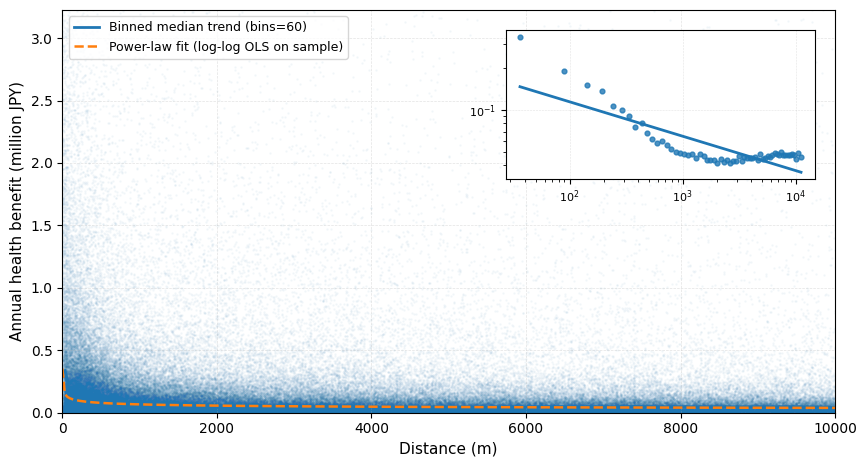

Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/src/fig2a_network_scatter_linear_millionJPY_with_binned_trend_inset_reproportioned.png
clipped% = 1.1275
[Sample all points] ln(sigma)=-1.067683  sigma=0.343804  beta=-0.237252  R2=0.0437
[Binned medians] ln(sigma)=-1.022377  sigma=0.359739  beta=-0.248267  R2=0.6608  bins_used=60


Sampling data_0_with_park_class.csv:   3%|▎         | 7.82M/250M [00:12<00:10, 23.1MB/s]

In [36]:
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =========================
# 1) 文件路径
# =========================
file0 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv"
file1 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv"
FILES = [file0, file1]

# =========================
# 2) 参数
# =========================
DIST_COL = "network_distance_m"
STATUS_COL = "route_status"
Y_COL = "steps"

CHUNKSIZE = 300_000
SEED = 123

# 货币化：保持和原文一致
JPY_PER_STEP = 0.04
POP_SCALE = 134.38
MONEY_MULT = JPY_PER_STEP * POP_SCALE
MONEY_UNIT = 1_000_000.0   # million JPY

# 图 a 参数
TARGET_SAMPLE_A = 200_000
N_BINS_A = 60
MIN_BIN_N_A = 200

# 字号：恢复到更接近原图的克制风格
TEXT_SCALE = 1.0
plt.rcParams.update({
    "font.size":        11 * TEXT_SCALE,
    "axes.labelsize":   11 * TEXT_SCALE,
    "xtick.labelsize":  10 * TEXT_SCALE,
    "ytick.labelsize":  10 * TEXT_SCALE,
    "legend.fontsize":   9 * TEXT_SCALE,
})

# =========================
# 3) 工具函数
# =========================
def ols_loglog(x, y):
    x = np.asarray(x, np.float64)
    y = np.asarray(y, np.float64)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]
    y = y[m]
    if x.size < 5:
        return np.nan, np.nan, np.nan

    lx = np.log(x)
    ly = np.log(y)

    n = lx.size
    sx = lx.sum()
    sy = ly.sum()
    sxx = (lx * lx).sum()
    sxy = (lx * ly).sum()
    denom = (n * sxx - sx * sx)

    if denom == 0:
        return np.nan, np.nan, np.nan

    beta = (n * sxy - sx * sy) / denom
    alpha = (sy - beta * sx) / n

    yhat = alpha + beta * lx
    ss_res = ((ly - yhat) ** 2).sum()
    ss_tot = ((ly - ly.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return float(alpha), float(beta), float(r2)


def binned_median_trend(dist, y, n_bins=60, min_bin_n=200):
    d = np.asarray(dist, np.float64)
    v = np.asarray(y, np.float64)

    m = np.isfinite(d) & np.isfinite(v) & (d > 0) & (v > 0)
    d = d[m]
    v = v[m]

    if d.size < 1000:
        return pd.DataFrame(columns=["bin", "n", "dist_med", "y_med"])

    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(d, qs)
    edges = np.unique(edges)

    if edges.size < 10:
        edges = np.linspace(d.min(), d.max(), n_bins + 1)

    bin_id = pd.cut(d, bins=edges, include_lowest=True, labels=False)
    tmp = pd.DataFrame({"bin": bin_id, "dist": d, "y": v})

    g = (
        tmp.groupby("bin", as_index=False)
           .agg(n=("y", "size"),
                dist_med=("dist", "median"),
                y_med=("y", "median"))
    )

    g = g[g["n"] >= min_bin_n].copy()
    g = g.sort_values("dist_med")
    return g


def stream_sample_network(files, usecols, chunksize=300_000, target_sample=200_000, seed=123):
    rng = np.random.default_rng(seed)
    parts = []
    kept = 0

    for fp in files:
        total_size = os.path.getsize(fp)
        pbar = tqdm(total=total_size, desc=f"Sampling {os.path.basename(fp)}", unit="B", unit_scale=True)

        for chunk in pd.read_csv(fp, usecols=usecols, chunksize=chunksize):
            pbar.update(int(chunk.memory_usage(deep=True).sum()))

            chunk = chunk.dropna(subset=usecols)
            chunk = chunk[
                (chunk[STATUS_COL] == "ok") &
                (chunk[DIST_COL] > 0) &
                (chunk[Y_COL] > 0)
            ]

            if len(chunk) == 0:
                continue

            remaining = target_sample - kept
            if remaining <= 0:
                break

            frac = min(1.0, remaining / max(len(chunk), 1))
            if frac < 1.0:
                take = chunk.sample(frac=frac, random_state=int(rng.integers(0, 1e9)))
            else:
                take = chunk

            parts.append(take.astype({
                DIST_COL: "float64",
                Y_COL: "float64"
            }))
            kept += len(take)

        pbar.close()

    df = pd.concat(parts, ignore_index=True)
    if len(df) > target_sample:
        df = df.sample(n=target_sample, random_state=seed)

    return df

# =========================
# 4) 读取抽样数据
# =========================
USECOLS_A = [DIST_COL, STATUS_COL, Y_COL]

df_a = stream_sample_network(
    FILES,
    usecols=USECOLS_A,
    chunksize=CHUNKSIZE,
    target_sample=TARGET_SAMPLE_A,
    seed=SEED
)

df_a["money_mjpy"] = (df_a[Y_COL] * MONEY_MULT) / MONEY_UNIT

# clip 比例：保持旧逻辑
YMAX_STEPS = 600_000
YMAX = (YMAX_STEPS * MONEY_MULT) / MONEY_UNIT
clip_ratio = float((df_a["money_mjpy"] > YMAX).mean())

# 60 bins 中位数趋势
trend_all = binned_median_trend(
    df_a[DIST_COL].to_numpy(),
    df_a["money_mjpy"].to_numpy(),
    n_bins=N_BINS_A,
    min_bin_n=MIN_BIN_N_A
)

# raw sample 的 log-log OLS
alpha_all, beta_all, r2_all = ols_loglog(
    df_a[DIST_COL].to_numpy(),
    df_a["money_mjpy"].to_numpy()
)

# binned medians 的 log-log OLS
if len(trend_all) > 0:
    alpha_bin, beta_bin, r2_bin = ols_loglog(
        trend_all["dist_med"].to_numpy(),
        trend_all["y_med"].to_numpy()
    )
else:
    alpha_bin, beta_bin, r2_bin = np.nan, np.nan, np.nan

sigma_all = np.exp(alpha_all) if np.isfinite(alpha_all) else np.nan
sigma_bin = np.exp(alpha_bin) if np.isfinite(alpha_bin) else np.nan

dpos = df_a.loc[df_a[DIST_COL] > 0, DIST_COL]
x_min = float(dpos.min()) if len(dpos) else 1.0
x_max = 10000

x_grid = np.linspace(x_min, x_max, 300)
y_fit_all = sigma_all * (x_grid ** beta_all) if (np.isfinite(sigma_all) and np.isfinite(beta_all)) else None

# =========================
# 5) 作图：按原图比例恢复
# =========================
fig, ax = plt.subplots(figsize=(8.8, 4.8))

# scatter
ax.scatter(
    df_a[DIST_COL],
    df_a["money_mjpy"],
    s=1,
    alpha=0.03,
    rasterized=True
)

# binned median trend
if len(trend_all) > 0:
    ax.plot(
        trend_all["dist_med"],
        trend_all["y_med"],
        linewidth=2.0,
        label=f"Binned median trend (bins={len(trend_all)})"
    )

# power-law fit on sample
if y_fit_all is not None:
    ax.plot(
        x_grid,
        y_fit_all,
        linewidth=1.8,
        linestyle="--",
        label="Power-law fit (log-log OLS on sample)"
    )

ax.set_xlim(0, x_max)
ax.set_ylim(0, YMAX)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Annual health benefit (million JPY)")

fmt = ScalarFormatter(useOffset=False)
fmt.set_scientific(False)
ax.yaxis.set_major_formatter(fmt)
ax.get_yaxis().get_offset_text().set_visible(False)

ax.margins(x=0, y=0)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)

# legend：左上，和原图一致
ax.legend(loc="upper left", frameon=True)

# inset：缩小、右上、不加标题，避免喧宾夺主
if len(trend_all) > 0 and np.isfinite(alpha_bin) and np.isfinite(beta_bin):
    axins = inset_axes(
        ax,
        width="40%", height="37%",
        loc="upper right",
        borderpad=1.6
    )

    axins.scatter(
        trend_all["dist_med"],
        trend_all["y_med"],
        s=12,
        alpha=0.8
    )

    x2 = np.linspace(trend_all["dist_med"].min(), trend_all["dist_med"].max(), 200)
    y2 = sigma_bin * (x2 ** beta_bin)
    axins.plot(x2, y2, linewidth=2.0)

    axins.set_xscale("log")
    axins.set_yscale("log")
    axins.tick_params(labelsize=8)
    axins.grid(True, linestyle="--", linewidth=0.4, alpha=0.35)

plt.tight_layout()
out_png = "fig2a_network_scatter_linear_millionJPY_with_binned_trend_inset_reproportioned.png"
plt.savefig(out_png, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", os.path.abspath(out_png))
print("clipped% =", clip_ratio * 100)
print(f"[Sample all points] ln(sigma)={alpha_all:.6f}  sigma={sigma_all:.6g}  beta={beta_all:.6f}  R2={r2_all:.4f}")
if len(trend_all) > 0:
    print(f"[Binned medians] ln(sigma)={alpha_bin:.6f}  sigma={sigma_bin:.6g}  beta={beta_bin:.6f}  R2={r2_bin:.4f}  bins_used={len(trend_all)}")

[INFO] groups: ['A', 'B', 'C', 'D', 'E']


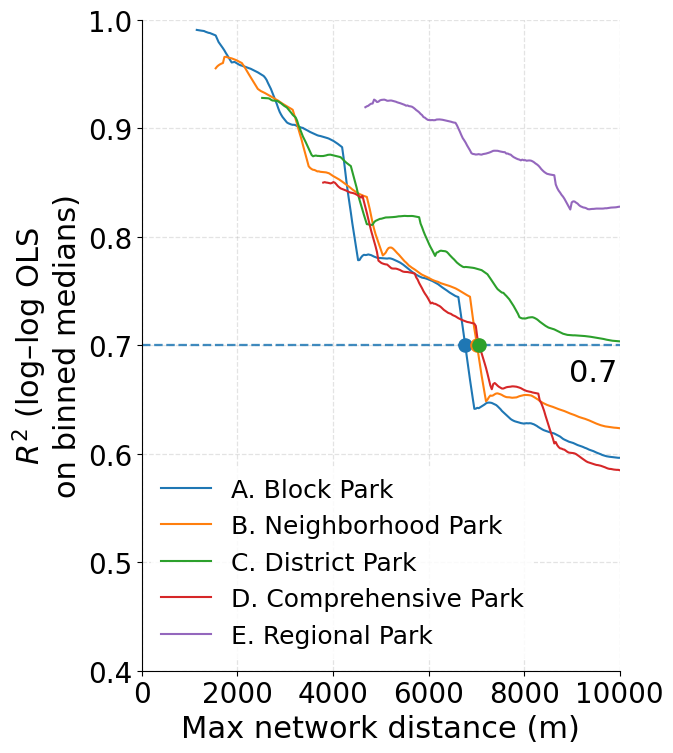

Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/src/fig2b_network_r2_vs_dmax_x10000_smooth.png

=== First crossing of R2 threshold (approx., based on smoothed curve) ===
A. Block Park           : ~6,768 m
B. Neighborhood Park    : ~7,015 m
C. District Park        : (no crossing / insufficient data)
D. Comprehensive Park   : ~7,060 m
E. Regional Park        : (no crossing / insufficient data)


In [26]:
# =========================
# Figure b: network distance cutoff stability
# =========================
USECOLS_B = [DIST_COL, STATUS_COL, PARK_CLASS_COL, Y_COL]

MAX_R2_DIST = 10_000   # 为了和旧版更好对照，先保持 10 km
R2_GRID_N = 320
Q_BINS_R2 = 10
MIN_BIN_N = 200
MIN_BINS_FOR_FIT = 6
MIN_POINTS_FOR_FIT = 3000
R2_HLINE = 0.7
SMOOTH_WIN = 11
SMOOTH_MIN_VALID = 6

df_b = read_network_full(FILES, usecols=USECOLS_B)
df_b["money_mjpy"] = (df_b[Y_COL].astype(float) * MONEY_MULT) / MONEY_UNIT

groups = [g for g in list("ABCDE") if g in set(df_b[PARK_CLASS_COL].unique())]
print("[INFO] groups:", groups)

dmax_grid = np.linspace(300, MAX_R2_DIST, R2_GRID_N)

fig, ax = plt.subplots(figsize=(7.2, 8.0))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

LW = 1 * TEXT_SCALE
DOT_S = 40 * (TEXT_SCALE ** 2)

cross_summary = []

for g in groups:
    sub = df_b[df_b[PARK_CLASS_COL] == g]
    label = LABEL_MAP.get(g, str(g))

    d_all = sub[DIST_COL].to_numpy(np.float64)
    y_all = sub["money_mjpy"].to_numpy(np.float64)

    m = np.isfinite(d_all) & np.isfinite(y_all) & (d_all > 0) & (y_all > 0)
    d_all = d_all[m]; y_all = y_all[m]

    if d_all.size < MIN_POINTS_FOR_FIT:
        ax.plot(dmax_grid, [np.nan]*len(dmax_grid), lw=LW, label=label)
        cross_summary.append((label, np.nan))
        continue

    order = np.argsort(d_all)
    d_all = d_all[order]
    y_all = y_all[order]

    edges = make_fixed_quantile_edges(d_all[d_all <= MAX_R2_DIST], Q_BINS_R2)
    if edges is None:
        ax.plot(dmax_grid, [np.nan]*len(dmax_grid), lw=LW, label=label)
        cross_summary.append((label, np.nan))
        continue

    r2s = []
    for dm in dmax_grid:
        idx = np.searchsorted(d_all, dm, side="right")
        if idx < MIN_POINTS_FOR_FIT:
            r2s.append(np.nan)
            continue

        agg = binned_median_with_edges(d_all[:idx], y_all[:idx], edges, min_bin_n=MIN_BIN_N)
        if agg is None or len(agg) < MIN_BINS_FOR_FIT:
            r2s.append(np.nan)
            continue

        _, _, r2 = ols_loglog(agg["d_med"].to_numpy(), agg["y_med"].to_numpy())
        r2s.append(r2)

    r2s = np.asarray(r2s, np.float64)
    r2s_sm = smooth_series_nan(r2s, win=SMOOTH_WIN, min_valid=SMOOTH_MIN_VALID)

    ax.plot(dmax_grid, r2s_sm, lw=LW, label=label)

    if R2_HLINE is not None:
        xc, ok = first_crossing_x(dmax_grid, r2s_sm, R2_HLINE)
        if ok:
            ax.scatter([xc], [R2_HLINE], s=DOT_S, zorder=6)
            cross_summary.append((label, xc))
        else:
            cross_summary.append((label, np.nan))

ax.set_xlabel("Max network distance (m)")
ax.set_ylabel(r"$R^2$ (log–log OLS" + "\n" + r"on binned medians)")
ax.set_xlim(0, MAX_R2_DIST)
ax.set_ylim(0.4, 1.0)
ax.grid(True, linestyle="--", linewidth=0.6 * TEXT_SCALE, alpha=0.35)

if R2_HLINE is not None:
    ax.axhline(R2_HLINE, linestyle="--", linewidth=1.1 * TEXT_SCALE, alpha=0.85)
    ax.text(MAX_R2_DIST * 0.995, R2_HLINE - 0.012, f"{R2_HLINE:.1f}",
            ha="right", va="top")

leg = ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.02, 0.02),
    frameon=True,
    framealpha=0.85,
    borderaxespad=0.0,
)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_edgecolor("none")

plt.tight_layout()
out2 = f"fig2b_network_r2_vs_dmax_x{MAX_R2_DIST}_smooth.png"
plt.savefig(out2, dpi=260, bbox_inches="tight")
plt.show()

print("Saved:", os.path.abspath(out2))
print("\n=== First crossing of R2 threshold (approx., based on smoothed curve) ===")
for lab, xc in cross_summary:
    if np.isfinite(xc):
        print(f"{lab:24s}: ~{xc:,.0f} m")
    else:
        print(f"{lab:24s}: (no crossing / insufficient data)")

Routed subset N = 1722492
Median steps = 8806.0
Median annual benefit (million JPY) = 0.04733401119999999


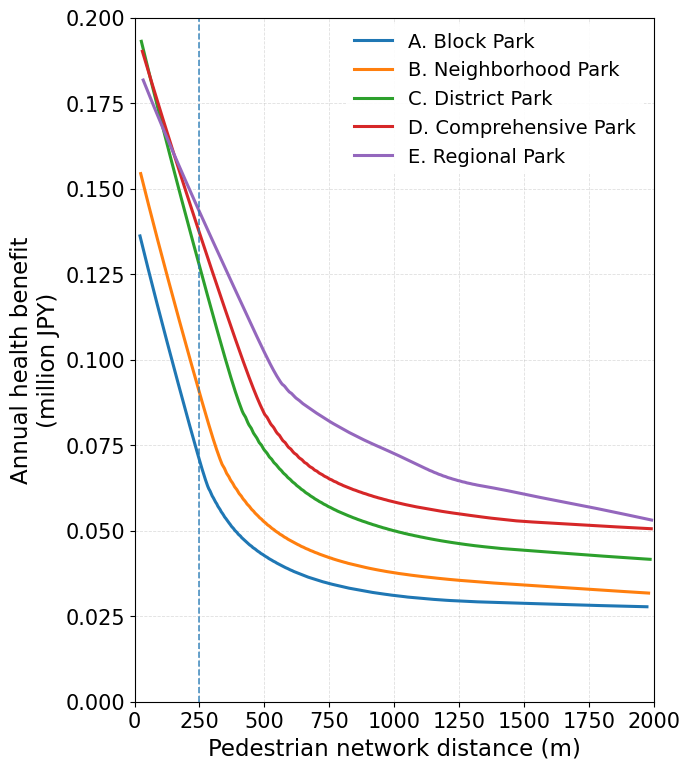

Saved figure: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/src/fig2c_network_loess_by_type_updated_ymax0.2.png

=== Type-specific power-law parameters using network distance ===


,Type,Park type name,N_raw_within_6000m,Bins_used,loge_sigma,sigma,beta,R2
0,A,Block Park,154196,60,-1.014680,0.362518,-0.326296,0.795331
1,B,Neighborhood Park,442266,60,-0.875813,0.416523,-0.321488,0.807729
2,C,District Park,326278,60,-0.554237,0.574510,-0.330661,0.837765
3,D,Comprehensive Park,264169,60,-0.931008,0.394156,-0.256285,0.763046
4,E,Regional Park,110503,60,-0.547790,0.578227,-0.297632,0.905573


Saved table: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/src/fig2c_network_type_equation_params_updated_ymax0.2.csv


In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# =========================
# 1) 文件路径
# =========================
file0 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv"
file1 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv"
FILES = [file0, file1]

# =========================
# 2) 参数
# =========================
DIST_COL = "network_distance_m"
STATUS_COL = "route_status"
PARK_CLASS_COL = "park_class"
STEP_COL = "steps"

# 货币化：保持与你原文一致
JPY_PER_STEP = 0.04
POP_SCALE = 134.38
MONEY_MULT = JPY_PER_STEP * POP_SCALE
MONEY_UNIT = 1_000_000.0   # million JPY

# 图 c 参数（保持和旧版尽量一致）
XLINE = 250
XMAX_PLOT = 2000
YMAX_PLOT = 0.2   # ===== 这里已经固定成 0.2 =====
MIN_DIST_CLEAN = 10
Q_BINS_PLOT = 100
LOESS_FRAC = 0.5

# 方程参数估计参数（更贴近你原文）
FIT_MAX = 6000           # 按 6 km 做类型参数表
FIT_BINS = 60            # 原文 Figure 2a/2b 用 60 bins
FIT_MIN_BIN_N = 30       # 每个 bin 至少 30 个点

TYPE_NAME = {
    "A": "Block Park",
    "B": "Neighborhood Park",
    "C": "District Park",
    "D": "Comprehensive Park",
    "E": "Regional Park",
}
LABEL_MAP = {
    "A": "A. Block Park",
    "B": "B. Neighborhood Park",
    "C": "C. District Park",
    "D": "D. Comprehensive Park",
    "E": "E. Regional Park",
}

# =========================
# 3) 版式
# =========================
TEXT_SCALE = 1.5
plt.rcParams.update({
    "font.size":        11 * TEXT_SCALE,
    "axes.labelsize":   11 * TEXT_SCALE,
    "xtick.labelsize":  10 * TEXT_SCALE,
    "ytick.labelsize":  10 * TEXT_SCALE,
    "legend.fontsize":   9 * TEXT_SCALE,
})

# =========================
# 4) 工具函数
# =========================
def quantile_binned_median(d, y, q_bins=100):
    d = np.asarray(d, np.float64)
    y = np.asarray(y, np.float64)

    m = np.isfinite(d) & np.isfinite(y) & (d > 0) & (y > 0)
    d = d[m]
    y = y[m]

    n = len(d)
    if n < max(400, q_bins * 8):
        return None

    qs = np.linspace(0, 1, q_bins + 1)
    edges = np.quantile(d, qs)
    edges = np.unique(edges)
    if len(edges) < 5:
        return None

    bid = np.searchsorted(edges, d, side="right") - 1
    ok = (bid >= 0) & (bid < len(edges) - 1)
    d = d[ok]
    y = y[ok]
    bid = bid[ok]

    dfb = pd.DataFrame({"bin": bid, "d": d, "y": y})
    agg = (
        dfb.groupby("bin")
           .agg(d_med=("d", "median"),
                y_med=("y", "median"),
                n=("y", "size"))
           .reset_index()
           .sort_values("d_med")
    )
    return agg


def loess_np(x, y, frac=0.5, x_new=None):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    idx = np.argsort(x)
    x = x[idx]
    y = y[idx]

    n = len(x)
    if n < 3:
        return x, y

    span = int(np.ceil(frac * n))
    span = max(3, min(span, n))

    if x_new is None:
        x_new = np.linspace(x.min(), x.max(), 450)
    else:
        x_new = np.asarray(x_new, dtype=np.float64)

    y_new = np.empty_like(x_new)

    for i, xi in enumerate(x_new):
        dist = np.abs(x - xi)
        nn_idx = np.argpartition(dist, span - 1)[:span]
        xk = x[nn_idx]
        yk = y[nn_idx]
        dk = dist[nn_idx]

        dmax = dk.max()
        if dmax <= 0:
            y_new[i] = yk.mean()
            continue

        u = dk / dmax
        w = (1 - u**3)**3

        X = np.column_stack([np.ones_like(xk), xk - xi])
        XtW = X.T * w
        A = XtW @ X
        b = XtW @ yk

        A[0, 0] += 1e-12
        A[1, 1] += 1e-12

        beta = np.linalg.solve(A, b)
        y_new[i] = beta[0]

    return x_new, y_new


def binned_median_for_fit(d, y, n_bins=60, min_bin_n=30):
    d = np.asarray(d, np.float64)
    y = np.asarray(y, np.float64)

    m = np.isfinite(d) & np.isfinite(y) & (d > 0) & (y > 0)
    d = d[m]
    y = y[m]

    if len(d) < max(300, n_bins * 5):
        return None

    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(d, qs)
    edges = np.unique(edges)

    if len(edges) < 5:
        return None

    bid = pd.cut(d, bins=edges, include_lowest=True, labels=False)
    tmp = pd.DataFrame({"bin": bid, "d": d, "y": y})

    agg = (
        tmp.groupby("bin", as_index=False)
           .agg(d_med=("d", "median"),
                y_med=("y", "median"),
                n=("y", "size"))
    )

    agg = agg[agg["n"] >= min_bin_n].copy()
    agg = agg.sort_values("d_med")

    if len(agg) < 5:
        return None

    return agg


def ols_loglog(x, y):
    x = np.asarray(x, np.float64)
    y = np.asarray(y, np.float64)

    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]
    y = y[m]

    if x.size < 5:
        return np.nan, np.nan, np.nan

    lx = np.log(x)
    ly = np.log(y)

    n = lx.size
    sx = lx.sum()
    sy = ly.sum()
    sxx = (lx * lx).sum()
    sxy = (lx * ly).sum()

    den = n * sxx - sx * sx
    if den == 0:
        return np.nan, np.nan, np.nan

    beta = (n * sxy - sx * sy) / den
    alpha = (sy - beta * sx) / n

    yhat = alpha + beta * lx
    ss_res = ((ly - yhat) ** 2).sum()
    ss_tot = ((ly - ly.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return float(alpha), float(beta), float(r2)

# =========================
# 5) 读取数据
# =========================
dfs = [pd.read_csv(f, low_memory=False) for f in FILES]
df_plot = pd.concat(dfs, ignore_index=True)

# 清洗：只保留 routed subset
df_plot = df_plot.dropna(subset=[STEP_COL, PARK_CLASS_COL, DIST_COL, STATUS_COL]).copy()
df_plot = df_plot[
    (df_plot[STATUS_COL] == "ok") &
    (df_plot[STEP_COL] > 0) &
    (df_plot[DIST_COL] >= MIN_DIST_CLEAN)
].copy()

df_plot[PARK_CLASS_COL] = df_plot[PARK_CLASS_COL].astype(str).str.strip()

# 货币化
df_plot["money_mjpy"] = df_plot[STEP_COL].astype(float) * MONEY_MULT / MONEY_UNIT

print("Routed subset N =", len(df_plot))
print("Median steps =", df_plot[STEP_COL].median())
print("Median annual benefit (million JPY) =", df_plot["money_mjpy"].median())

# =========================
# 6) 画图 c
# =========================
groups = [g for g in list("ABCDE") if g in set(df_plot[PARK_CLASS_COL].unique())]

Y_LABEL_2LINE = "Annual health benefit\n(million JPY)"

fig, ax = plt.subplots(figsize=(7.2, 8.0))
LW_MAIN  = 2.2
LW_VLINE = 1.2

param_rows = []

for g in groups:
    sub = df_plot[df_plot[PARK_CLASS_COL] == g].copy()

    # ---------- 图 c 曲线 ----------
    sub_plot = sub[sub[DIST_COL] <= XMAX_PLOT].copy()
    d_plot = sub_plot[DIST_COL].to_numpy()
    y_plot = sub_plot["money_mjpy"].to_numpy()

    if len(d_plot) >= 2000:
        agg_plot = quantile_binned_median(d_plot, y_plot, q_bins=Q_BINS_PLOT)
        if agg_plot is not None and len(agg_plot) >= 12:
            x_med = agg_plot["d_med"].to_numpy(np.float64)
            y_med = agg_plot["y_med"].to_numpy(np.float64)
            xl, yl = loess_np(x_med, y_med, frac=LOESS_FRAC)
            ax.plot(xl, yl, linewidth=LW_MAIN, label=LABEL_MAP.get(g, g))

    # ---------- 方程参数 ----------
    sub_fit = sub[sub[DIST_COL] <= FIT_MAX].copy()
    agg_fit = binned_median_for_fit(
        sub_fit[DIST_COL].to_numpy(),
        sub_fit["money_mjpy"].to_numpy(),
        n_bins=FIT_BINS,
        min_bin_n=FIT_MIN_BIN_N
    )

    if agg_fit is None:
        alpha, beta, r2 = np.nan, np.nan, np.nan
        n_fit = len(sub_fit)
        bins_used = 0
    else:
        alpha, beta, r2 = ols_loglog(
            agg_fit["d_med"].to_numpy(),
            agg_fit["y_med"].to_numpy()
        )
        n_fit = len(sub_fit)
        bins_used = len(agg_fit)

    param_rows.append({
        "Type": g,
        "Park type name": TYPE_NAME.get(g, ""),
        "N_raw_within_6000m": n_fit,
        "Bins_used": bins_used,
        "loge_sigma": alpha,
        "sigma": np.exp(alpha) if np.isfinite(alpha) else np.nan,
        "beta": beta,
        "R2": r2
    })

ax.axvline(XLINE, linestyle="--", linewidth=LW_VLINE, alpha=0.8)

ax.set_xlabel("Pedestrian network distance (m)")
ax.set_ylabel(Y_LABEL_2LINE)
ax.set_xlim(0, XMAX_PLOT)
ax.set_ylim(0, YMAX_PLOT)   # ===== 已经固定到 0.2 =====

ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)

fmt = ScalarFormatter(useOffset=False)
fmt.set_scientific(False)
ax.yaxis.set_major_formatter(fmt)
ax.get_yaxis().get_offset_text().set_visible(False)

leg = ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.98, 0.99),
    fontsize=14,
    frameon=True, framealpha=0.90,
    borderaxespad=0.0
)
leg.get_frame().set_edgecolor("none")

plt.tight_layout()
out_fig = "fig2c_network_loess_by_type_updated_ymax0.2.png"
plt.savefig(out_fig, dpi=260, bbox_inches="tight")
plt.show()
print("Saved figure:", os.path.abspath(out_fig))

# =========================
# 7) 输出每类公园的方程参数和 R2
# =========================
param_df = pd.DataFrame(param_rows).sort_values("Type")

print("\n=== Type-specific power-law parameters using network distance ===")
display(param_df)

out_table = "fig2c_network_type_equation_params_updated_ymax0.2.csv"
param_df.to_csv(out_table, index=False, encoding="utf-8-sig")
print("Saved table:", os.path.abspath(out_table))

合并后总行数: 1803980
列名: ['user_ID', 'Lat', 'Lng', 'osm_id', 'name', 'poly_ID_o', 'P13_004', 'area', 'dist_straight_m', 'visit_count', 'delta_time_total', 'steps', 'home_Lng', 'home_Lat', 'area_m2', 'park_class', 'park_class_name', 'network_distance_m', 'route_status', 'straight_distance_m_final', 'target_type_final', 'target_source_final']

用于分析的样本行数: 606072
network distance 中位数 (m): 599.7863131211232
visit_count 中位数: 1.0
delta_time_total 中位数 (s): 8984.0

=== Overall summary ===


,metric,value
0,time_ratio_oneway_n,606072.000000
1,time_ratio_oneway_median,0.089637
2,time_ratio_oneway_q1,0.031151
3,time_ratio_oneway_q3,0.239014
4,time_ratio_oneway_p90,0.522825
5,time_ratio_oneway_mean,0.279325
6,time_ratio_oneway_share_lt_0.10,0.530218
7,time_ratio_oneway_share_lt_0.25,0.760075
8,time_ratio_oneway_share_lt_0.50,0.893123
9,time_ratio_oneway_share_lt_1.00,0.971703



=== By park_class summary ===


,park_class,park_class_name,time_ratio_oneway_n,time_ratio_oneway_median,time_ratio_oneway_q1,time_ratio_oneway_q3,time_ratio_oneway_p90,time_ratio_oneway_mean,time_ratio_oneway_share_lt_0.10,time_ratio_oneway_share_lt_0.25,...,time_ratio_roundtrip_median,time_ratio_roundtrip_q1,time_ratio_roundtrip_q3,time_ratio_roundtrip_p90,time_ratio_roundtrip_mean,time_ratio_roundtrip_share_lt_0.10,time_ratio_roundtrip_share_lt_0.25,time_ratio_roundtrip_share_lt_0.50,time_ratio_roundtrip_share_lt_1.00,time_ratio_roundtrip_share_ge_1.00
0,A,Block Park,101281.0,0.074832,0.022602,0.221435,0.522788,0.257456,0.575626,0.773768,...,0.149665,0.045205,0.442869,1.045577,0.514912,0.401783,0.628716,0.773768,0.893761,0.106239
1,B,Neighborhood Park,255091.0,0.084379,0.028295,0.230407,0.510538,0.261932,0.546589,0.767510,...,0.168758,0.056590,0.460814,1.021075,0.523863,0.365132,0.603961,0.767510,0.896782,0.103218
2,C,District Park,144082.0,0.094680,0.035309,0.243759,0.524510,0.303126,0.515255,0.755882,...,0.189359,0.070618,0.487519,1.049021,0.606253,0.326675,0.577831,0.755882,0.892214,0.107786
3,D,Comprehensive Park,79623.0,0.107661,0.040927,0.260774,0.548568,0.298001,0.478229,0.738995,...,0.215323,0.081854,0.521549,1.097136,0.596003,0.295028,0.542846,0.738995,0.884945,0.115055
4,E,Regional Park,25995.0,0.123431,0.049160,0.276102,0.550994,0.346091,0.434814,0.721562,...,0.246861,0.098319,0.552205,1.101988,0.692183,0.253703,0.503635,0.721562,0.884824,0.115176



=== Share by ratio bin: one-way ===
time_ratio_oneway
<0.10        0.530218
0.10–0.25    0.229857
0.25–0.50    0.133049
0.50–1.00    0.078580
≥1.00        0.028297
Name: proportion, dtype: float64

=== Share by ratio bin: round-trip ===
time_ratio_roundtrip
<0.10        0.348125
0.10–0.25    0.241428
0.25–0.50    0.170521
0.50–1.00    0.133049
≥1.00        0.106877
Name: proportion, dtype: float64


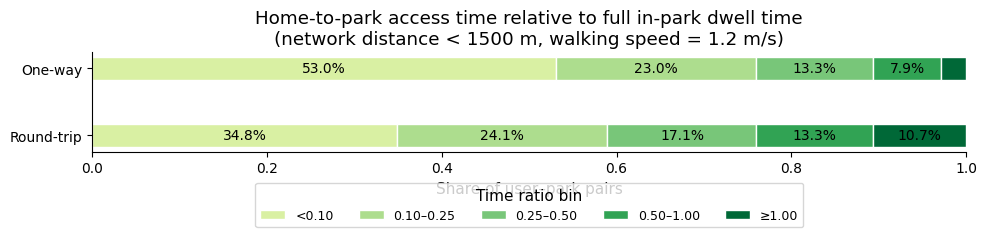


已保存图: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/access_vs_inpark_time_ratio_full_dwell_lt1500m_oneway_roundtrip.png
已保存明细: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/user_park_access_inpark_time_ratio_pair_level_full_dwell_lt1500m.csv
已保存整体汇总: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/user_park_access_inpark_time_ratio_summary_overall_full_dwell_lt1500m.csv
已保存分类型汇总: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/user_park_access_inpark_time_ratio_summary_by_park_class_full_dwell_lt1500m.csv


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# 1. 路径
# =========================================================
file0 = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv")
file1 = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv")
OUTPUT_DIR = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# 2. 参数
# =========================================================
WALK_SPEED_MPS = 1.2          # 步行速度 m/s
DIST_MAX_M = 1500             # 只分析 network distance < 1.5 km
USE_ROUTE_STATUS = "ok"       # 只用成功算出路网距离的 pair

BINS = [0, 0.1, 0.25, 0.5, 1, np.inf]
BIN_LABELS = ["<0.10", "0.10–0.25", "0.25–0.50", "0.50–1.00", "≥1.00"]

TYPE_NAME = {
    "A": "Block Park",
    "B": "Neighborhood Park",
    "C": "District Park",
    "D": "Comprehensive Park",
    "E": "Regional Park",
}

# =========================================================
# 3. 读取数据
# =========================================================
df0 = pd.read_csv(file0, low_memory=False)
df1 = pd.read_csv(file1, low_memory=False)

# =========================================================
# 4. 删除上一次这类分析残留的冗余列（仅内存，不改原文件）
# =========================================================
OLD_ANALYSIS_COLS = [
    "access_time_oneway_s",
    "access_time_roundtrip_s",
    "time_ratio_oneway",
    "time_ratio_roundtrip",
    "distance_group",
    "walk_access_flag",
    "inpark_active_time_s",
    "benefit_ratio_oneway",
    "benefit_ratio_roundtrip"
]

df0 = df0.drop(columns=[c for c in OLD_ANALYSIS_COLS if c in df0.columns], errors="ignore")
df1 = df1.drop(columns=[c for c in OLD_ANALYSIS_COLS if c in df1.columns], errors="ignore")

df = pd.concat([df0, df1], ignore_index=True)

print("合并后总行数:", len(df))
print("列名:", df.columns.tolist())

# =========================================================
# 5. 基础检查
# =========================================================
need_cols = [
    "user_ID", "osm_id",
    "visit_count", "delta_time_total",
    "network_distance_m", "route_status", "park_class"
]
missing_cols = [c for c in need_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"缺少这些列: {missing_cols}")

for c in ["visit_count", "delta_time_total", "network_distance_m"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["park_class"] = df["park_class"].astype(str).str.strip()

# =========================================================
# 6. 只保留近距离步行可达样本
# =========================================================
df_use = df[
    (df["route_status"] == USE_ROUTE_STATUS) &
    df["visit_count"].notna() &
    df["delta_time_total"].notna() &
    df["network_distance_m"].notna() &
    (df["visit_count"] > 0) &
    (df["delta_time_total"] > 0) &
    (df["network_distance_m"] > 0) &
    (df["network_distance_m"] < DIST_MAX_M)
].copy()

print("\n用于分析的样本行数:", len(df_use))
print("network distance 中位数 (m):", df_use["network_distance_m"].median())
print("visit_count 中位数:", df_use["visit_count"].median())
print("delta_time_total 中位数 (s):", df_use["delta_time_total"].median())

# =========================================================
# 7. 计算时间与比例
# =========================================================
# 单程：每次 visit 都假设从 home 步行到 park
df_use["access_time_oneway_s"] = (
    df_use["visit_count"] * df_use["network_distance_m"] / WALK_SPEED_MPS
)

# 往返：每次 visit 都假设从 home 步行到 park 再返回
df_use["access_time_roundtrip_s"] = 2.0 * df_use["access_time_oneway_s"]

# 时间比：access time / full in-park dwell time
df_use["time_ratio_oneway"] = df_use["access_time_oneway_s"] / df_use["delta_time_total"]
df_use["time_ratio_roundtrip"] = df_use["access_time_roundtrip_s"] / df_use["delta_time_total"]

# =========================================================
# 8. 汇总函数
# =========================================================
def summarize_ratio(series, prefix):
    s = pd.to_numeric(series, errors="coerce")
    s = s[np.isfinite(s) & (s >= 0)]

    if len(s) == 0:
        return pd.Series({
            f"{prefix}_n": 0,
            f"{prefix}_median": np.nan,
            f"{prefix}_q1": np.nan,
            f"{prefix}_q3": np.nan,
            f"{prefix}_p90": np.nan,
            f"{prefix}_mean": np.nan,
            f"{prefix}_share_lt_0.10": np.nan,
            f"{prefix}_share_lt_0.25": np.nan,
            f"{prefix}_share_lt_0.50": np.nan,
            f"{prefix}_share_lt_1.00": np.nan,
            f"{prefix}_share_ge_1.00": np.nan,
        })

    return pd.Series({
        f"{prefix}_n": len(s),
        f"{prefix}_median": s.median(),
        f"{prefix}_q1": s.quantile(0.25),
        f"{prefix}_q3": s.quantile(0.75),
        f"{prefix}_p90": s.quantile(0.90),
        f"{prefix}_mean": s.mean(),
        f"{prefix}_share_lt_0.10": (s < 0.10).mean(),
        f"{prefix}_share_lt_0.25": (s < 0.25).mean(),
        f"{prefix}_share_lt_0.50": (s < 0.50).mean(),
        f"{prefix}_share_lt_1.00": (s < 1.00).mean(),
        f"{prefix}_share_ge_1.00": (s >= 1.00).mean(),
    })

def bin_shares(series, bins, labels):
    s = pd.to_numeric(series, errors="coerce")
    s = s[np.isfinite(s) & (s >= 0)]
    cats = pd.cut(s, bins=bins, labels=labels, right=False, include_lowest=True)
    out = cats.value_counts(normalize=True).reindex(labels, fill_value=0.0)
    return out

# =========================================================
# 9. 整体汇总
# =========================================================
summary_overall = pd.concat([
    summarize_ratio(df_use["time_ratio_oneway"], "time_ratio_oneway"),
    summarize_ratio(df_use["time_ratio_roundtrip"], "time_ratio_roundtrip"),
])

summary_overall = summary_overall.to_frame(name="value").reset_index().rename(columns={"index": "metric"})

print("\n=== Overall summary ===")
display(summary_overall)

# =========================================================
# 10. 按 park_class 汇总
# =========================================================
by_class_rows = []
for g in sorted(df_use["park_class"].dropna().unique()):
    sub = df_use[df_use["park_class"] == g].copy()

    row = {"park_class": g, "park_class_name": TYPE_NAME.get(g, g)}
    row.update(summarize_ratio(sub["time_ratio_oneway"], "time_ratio_oneway").to_dict())
    row.update(summarize_ratio(sub["time_ratio_roundtrip"], "time_ratio_roundtrip").to_dict())
    by_class_rows.append(row)

summary_by_class = pd.DataFrame(by_class_rows)

print("\n=== By park_class summary ===")
display(summary_by_class)

# =========================================================
# 11. 颜色条分布（单程 / 往返）
# =========================================================
shares_oneway = bin_shares(df_use["time_ratio_oneway"], BINS, BIN_LABELS)
shares_roundtrip = bin_shares(df_use["time_ratio_roundtrip"], BINS, BIN_LABELS)

print("\n=== Share by ratio bin: one-way ===")
print(shares_oneway)

print("\n=== Share by ratio bin: round-trip ===")
print(shares_roundtrip)

# =========================================================
# 12. 绘制两条水平颜色条
# =========================================================
colors = ["#d9f0a3", "#addd8e", "#78c679", "#31a354", "#006837"]

fig, ax = plt.subplots(figsize=(10, 2.8))

y_positions = [1, 0]
labels = ["One-way", "Round-trip"]
share_table = [shares_oneway, shares_roundtrip]

for y, lab, shares in zip(y_positions, labels, share_table):
    left = 0
    for color, bin_lab in zip(colors, BIN_LABELS):
        width = shares[bin_lab]
        ax.barh(y, width, left=left, height=0.35, color=color, edgecolor="white")
        if width >= 0.04:
            ax.text(left + width / 2, y, f"{width*100:.1f}%", ha="center", va="center", fontsize=10)
        left += width

ax.set_xlim(0, 1)
ax.set_yticks(y_positions)
ax.set_yticklabels(labels)
ax.set_xlabel("Share of user–park pairs")
ax.set_title(
    f"Home-to-park access time relative to full in-park dwell time\n"
    f"(network distance < {DIST_MAX_M} m, walking speed = {WALK_SPEED_MPS:.1f} m/s)"
)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, edgecolor="white", label=l) for c, l in zip(colors, BIN_LABELS)]
ax.legend(handles=legend_handles, title="Time ratio bin", ncol=5, bbox_to_anchor=(0.5, -0.25), loc="upper center")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

fig_path = OUTPUT_DIR / "access_vs_inpark_time_ratio_full_dwell_lt1500m_oneway_roundtrip.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\n已保存图:", fig_path)

# =========================================================
# 13. 输出结果文件
# =========================================================
pair_out = OUTPUT_DIR / "user_park_access_inpark_time_ratio_pair_level_full_dwell_lt1500m.csv"
overall_out = OUTPUT_DIR / "user_park_access_inpark_time_ratio_summary_overall_full_dwell_lt1500m.csv"
class_out = OUTPUT_DIR / "user_park_access_inpark_time_ratio_summary_by_park_class_full_dwell_lt1500m.csv"

pair_cols = [
    "user_ID", "osm_id", "park_class",
    "visit_count", "delta_time_total",
    "network_distance_m", "route_status",
    "access_time_oneway_s", "access_time_roundtrip_s",
    "time_ratio_oneway", "time_ratio_roundtrip"
]
pair_cols = [c for c in pair_cols if c in df_use.columns]

df_use[pair_cols].to_csv(pair_out, index=False, encoding="utf-8-sig")
summary_overall.to_csv(overall_out, index=False, encoding="utf-8-sig")
summary_by_class.to_csv(class_out, index=False, encoding="utf-8-sig")

print("已保存明细:", pair_out)
print("已保存整体汇总:", overall_out)
print("已保存分类型汇总:", class_out)

总行数: 1803980
近距离 routed 子样本行数: 606072

=== Key result: percentage increase relative to original baseline ===
One-way access walking would increase total monetized benefit by: 1.96%
Round-trip access walking would increase total monetized benefit by: 3.91%


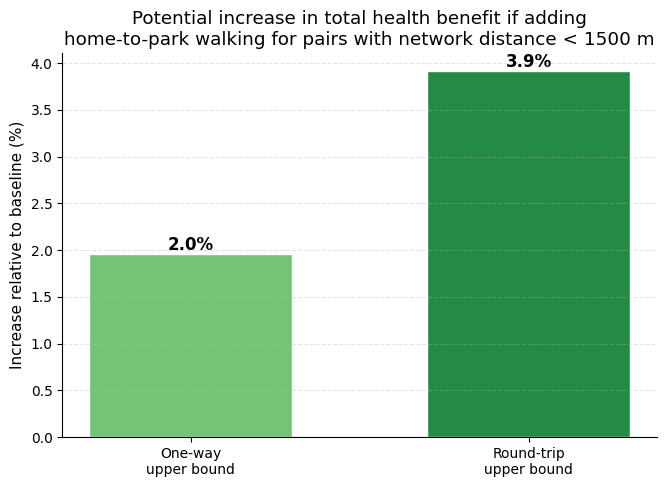


已保存图: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/benefit_increase_ratio_if_adding_access_walking_lt1500m.png


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# 1. 路径
# =========================================================
file0 = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv")
file1 = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv")
OUTPUT_DIR = Path("/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# 2. 参数
# =========================================================
DIST_MAX_M = 1500          # 只把 <1.5 km 视为可能步行到园
WALK_SPEED_MPS = 1.2       # 假定步行速度 m/s
CADENCE = 1.2              # 假定步频 steps/s
JPY_PER_STEP = 0.04
POP_SCALE = 134.38
USE_ROUTE_STATUS = "ok"

# =========================================================
# 3. 读取数据
# =========================================================
df0 = pd.read_csv(file0, low_memory=False)
df1 = pd.read_csv(file1, low_memory=False)
df = pd.concat([df0, df1], ignore_index=True)

print("总行数:", len(df))

# =========================================================
# 4. 基础清洗
# =========================================================
need_cols = ["steps", "visit_count", "network_distance_m", "route_status"]
missing_cols = [c for c in need_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"缺少这些列: {missing_cols}")

for c in ["steps", "visit_count", "network_distance_m"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# =========================================================
# 5. baseline：严格沿用原文口径
#    注意：这里的 steps 已经隐含了你原文的 0.6 × 1.2 假设
# =========================================================
df["baseline_inpark_benefit_jpy"] = df["steps"] * JPY_PER_STEP * POP_SCALE

# 近距离 routed 子样本：作为“可能步行到园”的保守子样本
near_mask = (
    (df["route_status"] == USE_ROUTE_STATUS) &
    df["visit_count"].notna() &
    df["network_distance_m"].notna() &
    (df["visit_count"] > 0) &
    (df["network_distance_m"] > 0) &
    (df["network_distance_m"] < DIST_MAX_M)
)

df_near = df.loc[near_mask].copy()

print("近距离 routed 子样本行数:", len(df_near))

# =========================================================
# 6. 计算 hypothetical access-trip benefit
#    这里是上界假设：每次都从 home 出发，且全程步行
# =========================================================
# 单程 access steps
df_near["access_steps_oneway"] = (
    df_near["visit_count"] * (df_near["network_distance_m"] / WALK_SPEED_MPS) * CADENCE
)

# 往返 access steps
df_near["access_steps_roundtrip"] = 2.0 * df_near["access_steps_oneway"]

# 换算成收益（口径与主文一致）
df_near["access_benefit_oneway_jpy"] = df_near["access_steps_oneway"] * JPY_PER_STEP * POP_SCALE
df_near["access_benefit_roundtrip_jpy"] = df_near["access_steps_roundtrip"] * JPY_PER_STEP * POP_SCALE

# =========================================================
# 7. 计算增长比例（这是你真正关心的）
# =========================================================
baseline_total_jpy = df.loc[
    df["baseline_inpark_benefit_jpy"].notna() & (df["baseline_inpark_benefit_jpy"] > 0),
    "baseline_inpark_benefit_jpy"
].sum()

added_oneway_jpy = df_near["access_benefit_oneway_jpy"].sum()
added_roundtrip_jpy = df_near["access_benefit_roundtrip_jpy"].sum()

increase_pct_oneway = added_oneway_jpy / baseline_total_jpy if baseline_total_jpy > 0 else np.nan
increase_pct_roundtrip = added_roundtrip_jpy / baseline_total_jpy if baseline_total_jpy > 0 else np.nan

# =========================================================
# 8. 打印核心结果（只强调增长比例）
# =========================================================
print("\n=== Key result: percentage increase relative to original baseline ===")
print(f"One-way access walking would increase total monetized benefit by: {increase_pct_oneway:.2%}")
print(f"Round-trip access walking would increase total monetized benefit by: {increase_pct_roundtrip:.2%}")

# =========================================================
# 9. 作图：只画增长比例
# =========================================================
labels = ["One-way\nupper bound", "Round-trip\nupper bound"]
values = [increase_pct_oneway * 100, increase_pct_roundtrip * 100]
colors = ["#74c476", "#238b45"]

fig, ax = plt.subplots(figsize=(6.8, 5.0))

bars = ax.bar(labels, values, color=colors, edgecolor="white", width=0.6)

for rect, val in zip(bars, values):
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height(),
        f"{val:.1f}%",
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )

ax.set_ylabel("Increase relative to baseline (%)")
ax.set_title(
    f"Potential increase in total health benefit if adding\n"
    f"home-to-park walking for pairs with network distance < {DIST_MAX_M} m"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()

fig_path = OUTPUT_DIR / "benefit_increase_ratio_if_adding_access_walking_lt1500m.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\n已保存图:", fig_path)

Rows after cleaning: 1,747,158
Park types used: ['City block park', 'Neighborhood Park', 'District Park', 'Comprehensive Park', 'Regional Park']


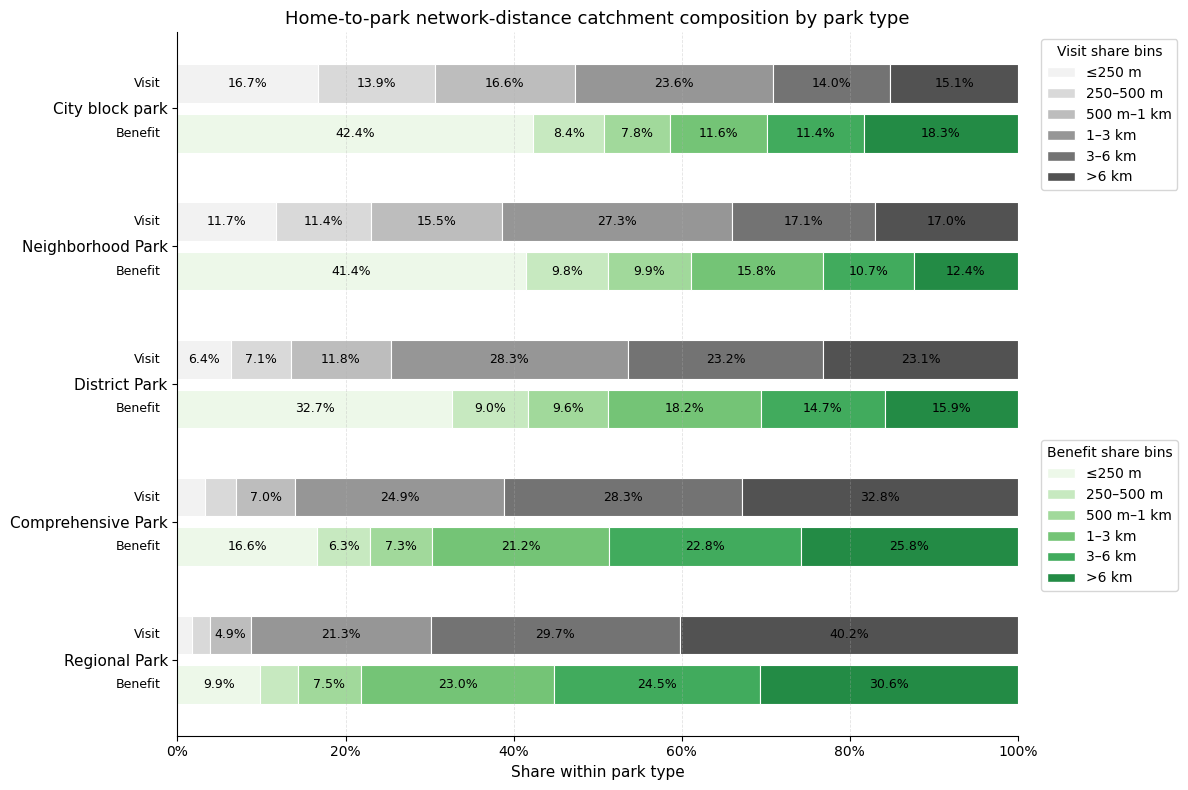

Saved plot: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/catchment_pattern/catchment_composition_stacked_bar.png
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/catchment_pattern/catchment_distance_summary.csv
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/catchment_pattern/catchment_share_summary.csv
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/catchment_pattern/catchment_tail_concentration_summary.csv

===== Distance summary =====


,park_type,n_visits,median_distance_m,p25_distance_m,p75_distance_m,iqr_distance_m,p80_distance_m,p90_distance_m,share_within_250m_pct,share_within_500m_pct,share_within_1km_pct,share_within_3km_pct,share_within_6km_pct,share_beyond_6km_visits_pct
0,City block park,188978,1124.739959,389.069435,3711.963323,3322.893887,4763.548652,7528.232159,16.703532,30.634783,47.254178,70.894496,84.850088,15.149912
1,Neighborhood Park,546529,1584.730526,547.916231,4346.986469,3799.070238,5322.077209,7793.630362,11.709168,23.077092,38.621555,65.950755,83.048109,16.951891
2,District Park,430078,2653.587427,982.767308,5687.078789,4704.311481,6559.845616,8543.215619,6.363497,13.506852,25.356563,53.652128,76.881868,23.118132
3,Comprehensive Park,396053,4048.969740,1845.823328,7034.857834,5189.034506,7727.597428,9259.544250,3.231386,7.009163,13.959495,38.892269,67.235951,32.764049
4,Regional Park,185520,4929.427257,2512.299617,7670.423383,5158.123765,8230.189604,9409.018401,1.716257,3.850798,8.786115,30.117508,59.781156,40.218844



===== Share summary =====


,park_type,visit_share_≤250 m,visit_share_250–500 m,visit_share_500 m–1 km,visit_share_1–3 km,visit_share_3–6 km,visit_share_>6 km,benefit_share_≤250 m,benefit_share_250–500 m,benefit_share_500 m–1 km,benefit_share_1–3 km,benefit_share_3–6 km,benefit_share_>6 km,share_beyond_6km_visits_pct,share_beyond_6km_benefits_pct
0,City block park,16.703532,13.931251,16.619395,23.640318,13.955593,15.149912,42.371788,8.421324,7.781158,11.634437,11.442368,18.348925,15.149912,18.348925
1,Neighborhood Park,11.709168,11.367924,15.544463,27.329199,17.097354,16.951891,41.435626,9.779007,9.850854,15.808964,10.725818,12.399731,16.951891,12.399731
2,District Park,6.363497,7.143355,11.849711,28.295565,23.229740,23.118132,32.693944,8.992311,9.611466,18.154656,14.693762,15.853859,23.118132,15.853859
3,Comprehensive Park,3.231386,3.777777,6.950332,24.932774,28.343681,32.764049,16.633786,6.303944,7.299476,21.170139,22.787592,25.805062,32.764049,25.805062
4,Regional Park,1.716257,2.134541,4.935317,21.331393,29.663648,40.218844,9.880141,4.460445,7.480005,23.016359,24.545358,30.617693,40.218844,30.617693



===== Tail concentration summary (>6 km) =====


,park_type,n_tail_visits,top1_tail_visit_share_pct,top5_tail_visit_share_pct,top10_tail_visit_share_pct,top1_tail_benefit_share_pct,top5_tail_benefit_share_pct,top10_tail_benefit_share_pct
0,City block park,28630,5.410409,18.417744,24.799162,44.443778,57.966798,63.746958
1,Neighborhood Park,92647,6.613274,15.239565,22.443252,6.601462,16.158696,23.612894
2,District Park,99426,6.311226,19.430531,29.381651,13.491930,33.032152,43.939589
3,Comprehensive Park,129763,6.706842,27.970993,38.796113,11.216721,35.765250,45.769655
4,Regional Park,74614,33.844855,65.707508,85.778808,34.751969,66.219558,85.915225


In [1]:
# =========================
# Catchment composition by park type
# Two horizontal stacked bars per park type:
#   1) Visit share
#   2) Benefit share
# =========================

from __future__ import annotations

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# =========================================================
# 0. USER CONFIG
# =========================================================

FILE_1 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv"
FILE_2 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv"

OUTPUT_DIR = Path(
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/catchment_pattern"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# core columns
DIST_COL = "network_distance_m"
STEPS_COL = "steps"
PARK_CLASS_COL = "park_class"
PARK_CLASS_NAME_COL = "park_class_name"

# optional weighting
# 如果你当前CSV里没有人口权重列，就保持 None
WEIGHT_COL = None   # e.g. "rep_weight"

# step value
# 只影响 benefit 的绝对值，不影响 benefit share；
# 但这里仍保留，便于后续扩展
STEP_VALUE_JPY = 0.04056   # 2017 value converted to constant 2019 JPY

# distance bins
BIN_EDGES = [0, 250, 500, 1000, 3000, 6000, np.inf]
BIN_LABELS = ["≤250 m", "250–500 m", "500 m–1 km", "1–3 km", "3–6 km", ">6 km"]

# display order
PARK_TYPE_ORDER = [
    "City block park",
    "Neighborhood Park",
    "District Park",
    "Comprehensive Park",
    "Regional Park",
]

# colors
VISIT_COLORS = ["#f2f2f2", "#d9d9d9", "#bdbdbd", "#969696", "#737373", "#525252"]
BENEFIT_COLORS = ["#edf8e9", "#c7e9c0", "#a1d99b", "#74c476", "#41ab5d", "#238b45"]

# plotting
FIG_W = 12
FIG_H = 8
LABEL_MIN_SHARE = 0.045   # only label segments >= 4.5% to avoid clutter

# =========================================================
# 1. READ DATA
# =========================================================

df1 = pd.read_csv(FILE_1)
df2 = pd.read_csv(FILE_2)
df = pd.concat([df1, df2], ignore_index=True).copy()

# basic checks
required_cols = [DIST_COL, STEPS_COL, PARK_CLASS_COL, PARK_CLASS_NAME_COL]
for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Missing required column: {c}")

# clean
df[DIST_COL] = pd.to_numeric(df[DIST_COL], errors="coerce")
df[STEPS_COL] = pd.to_numeric(df[STEPS_COL], errors="coerce")

if WEIGHT_COL is not None:
    if WEIGHT_COL not in df.columns:
        raise ValueError(f"WEIGHT_COL='{WEIGHT_COL}' not found in dataframe.")
    df[WEIGHT_COL] = pd.to_numeric(df[WEIGHT_COL], errors="coerce")
else:
    df["__weight__"] = 1.0
    WEIGHT_COL = "__weight__"

df = df.dropna(subset=[DIST_COL, STEPS_COL, PARK_CLASS_NAME_COL]).copy()
df = df[(df[DIST_COL] >= 0) & (df[STEPS_COL] >= 0)].copy()

# benefit
df["visit_weight"] = df[WEIGHT_COL].astype(float)
df["benefit_jpy"] = df[STEPS_COL].astype(float) * STEP_VALUE_JPY * df["visit_weight"]

# distance bins
df["dist_bin"] = pd.cut(
    df[DIST_COL],
    bins=BIN_EDGES,
    labels=BIN_LABELS,
    include_lowest=True,
    right=True,
)

# keep only defined park types if present
existing_types = [x for x in PARK_TYPE_ORDER if x in set(df[PARK_CLASS_NAME_COL].astype(str))]
if len(existing_types) == 0:
    existing_types = sorted(df[PARK_CLASS_NAME_COL].dropna().astype(str).unique().tolist())

df[PARK_CLASS_NAME_COL] = pd.Categorical(df[PARK_CLASS_NAME_COL], categories=existing_types, ordered=True)
df = df.sort_values(PARK_CLASS_NAME_COL).copy()

print(f"Rows after cleaning: {len(df):,}")
print(f"Park types used: {existing_types}")

# =========================================================
# 2. SUMMARY TABLES
# =========================================================

# ---------- distance summary by park type ----------
distance_rows = []
for ptype, g in df.groupby(PARK_CLASS_NAME_COL, observed=True):
    dist = g[DIST_COL].to_numpy(float)
    if len(dist) == 0:
        continue
    q25, q50, q75 = np.percentile(dist, [25, 50, 75])
    p80, p90 = np.percentile(dist, [80, 90])

    distance_rows.append({
        "park_type": ptype,
        "n_visits": len(g),
        "median_distance_m": q50,
        "p25_distance_m": q25,
        "p75_distance_m": q75,
        "iqr_distance_m": q75 - q25,
        "p80_distance_m": p80,
        "p90_distance_m": p90,
        "share_within_250m_pct": 100 * (dist <= 250).mean(),
        "share_within_500m_pct": 100 * (dist <= 500).mean(),
        "share_within_1km_pct": 100 * (dist <= 1000).mean(),
        "share_within_3km_pct": 100 * (dist <= 3000).mean(),
        "share_within_6km_pct": 100 * (dist <= 6000).mean(),
        "share_beyond_6km_visits_pct": 100 * (dist > 6000).mean(),
    })

distance_summary = pd.DataFrame(distance_rows)

# ---------- visit share by distance bin ----------
visit_bin = (
    df.groupby([PARK_CLASS_NAME_COL, "dist_bin"], observed=True)["visit_weight"]
      .sum()
      .reset_index(name="visit_weight_sum")
)

visit_totals = (
    visit_bin.groupby(PARK_CLASS_NAME_COL, observed=True)["visit_weight_sum"]
    .sum()
    .reset_index(name="visit_total")
)

visit_bin = visit_bin.merge(visit_totals, on=PARK_CLASS_NAME_COL, how="left")
visit_bin["visit_share"] = visit_bin["visit_weight_sum"] / visit_bin["visit_total"]

visit_share_wide = (
    visit_bin.pivot(index=PARK_CLASS_NAME_COL, columns="dist_bin", values="visit_share")
    .reindex(index=existing_types, columns=BIN_LABELS)
    .fillna(0.0)
)

# ---------- benefit share by distance bin ----------
benefit_bin = (
    df.groupby([PARK_CLASS_NAME_COL, "dist_bin"], observed=True)["benefit_jpy"]
      .sum()
      .reset_index(name="benefit_sum")
)

benefit_totals = (
    benefit_bin.groupby(PARK_CLASS_NAME_COL, observed=True)["benefit_sum"]
    .sum()
    .reset_index(name="benefit_total")
)

benefit_bin = benefit_bin.merge(benefit_totals, on=PARK_CLASS_NAME_COL, how="left")
benefit_bin["benefit_share"] = benefit_bin["benefit_sum"] / benefit_bin["benefit_total"]

benefit_share_wide = (
    benefit_bin.pivot(index=PARK_CLASS_NAME_COL, columns="dist_bin", values="benefit_share")
    .reindex(index=existing_types, columns=BIN_LABELS)
    .fillna(0.0)
)

# ---------- combined share summary ----------
share_summary = pd.DataFrame({"park_type": existing_types})

for lab in BIN_LABELS:
    share_summary[f"visit_share_{lab}"] = visit_share_wide[lab].values * 100
for lab in BIN_LABELS:
    share_summary[f"benefit_share_{lab}"] = benefit_share_wide[lab].values * 100

share_summary["share_beyond_6km_visits_pct"] = visit_share_wide[">6 km"].values * 100
share_summary["share_beyond_6km_benefits_pct"] = benefit_share_wide[">6 km"].values * 100

# ---------- tail concentration (>6 km) ----------
tail_df = df[df[DIST_COL] > 6000].copy()

tail_rows = []
if len(tail_df) > 0:
    for ptype, g in tail_df.groupby(PARK_CLASS_NAME_COL, observed=True):
        park_visit = (
            g.groupby("osm_id", dropna=False)["visit_weight"]
            .sum()
            .sort_values(ascending=False)
        )
        park_benefit = (
            g.groupby("osm_id", dropna=False)["benefit_jpy"]
            .sum()
            .sort_values(ascending=False)
        )

        total_visit = park_visit.sum()
        total_benefit = park_benefit.sum()

        def top_share(series, n):
            if len(series) == 0 or series.sum() == 0:
                return np.nan
            return 100 * series.head(n).sum() / series.sum()

        tail_rows.append({
            "park_type": ptype,
            "n_tail_visits": len(g),
            "top1_tail_visit_share_pct": top_share(park_visit, 1),
            "top5_tail_visit_share_pct": top_share(park_visit, 5),
            "top10_tail_visit_share_pct": top_share(park_visit, 10),
            "top1_tail_benefit_share_pct": top_share(park_benefit, 1),
            "top5_tail_benefit_share_pct": top_share(park_benefit, 5),
            "top10_tail_benefit_share_pct": top_share(park_benefit, 10),
        })

tail_summary = pd.DataFrame(tail_rows)

# =========================================================
# 3. PLOT: TWO STACKED BARS PER PARK TYPE
# =========================================================

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# positions
n_types = len(existing_types)
base_positions = np.arange(n_types)[::-1]  # top-to-bottom
y_visit = base_positions + 0.18
y_benefit = base_positions - 0.18

bar_h = 0.28

# draw visit bars
left = np.zeros(n_types)
for i, lab in enumerate(BIN_LABELS):
    vals = visit_share_wide[lab].values
    ax.barh(
        y_visit,
        vals,
        left=left,
        height=bar_h,
        color=VISIT_COLORS[i],
        edgecolor="white",
        linewidth=0.8,
        label=lab if i == 0 else None  # legend handled separately
    )
    # labels
    for j, v in enumerate(vals):
        if v >= LABEL_MIN_SHARE:
            ax.text(
                left[j] + v / 2,
                y_visit[j],
                f"{v*100:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="black"
            )
    left += vals

# draw benefit bars
left = np.zeros(n_types)
for i, lab in enumerate(BIN_LABELS):
    vals = benefit_share_wide[lab].values
    ax.barh(
        y_benefit,
        vals,
        left=left,
        height=bar_h,
        color=BENEFIT_COLORS[i],
        edgecolor="white",
        linewidth=0.8
    )
    for j, v in enumerate(vals):
        if v >= LABEL_MIN_SHARE:
            ax.text(
                left[j] + v / 2,
                y_benefit[j],
                f"{v*100:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="black"
            )
    left += vals

# y tick labels on center
ax.set_yticks(base_positions)
ax.set_yticklabels(existing_types, fontsize=11)

# add small row labels on left
for i in range(n_types):
    ax.text(-0.02, y_visit[i], "Visit", ha="right", va="center", fontsize=9, transform=ax.get_yaxis_transform())
    ax.text(-0.02, y_benefit[i], "Benefit", ha="right", va="center", fontsize=9, transform=ax.get_yaxis_transform())

# x axis
ax.set_xlim(0, 1)
ax.set_xlabel("Share within park type", fontsize=11)

# x ticks as percentages
xticks = np.linspace(0, 1, 6)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{int(x*100)}%" for x in xticks])

# title
ax.set_title("Home-to-park network-distance catchment composition by park type", fontsize=13)

# grid
ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.35)

# custom legends: one for bins (visit colors), one for metric colors
from matplotlib.patches import Patch

legend_bins_visit = [
    Patch(facecolor=VISIT_COLORS[i], edgecolor="white", label=BIN_LABELS[i])
    for i in range(len(BIN_LABELS))
]
legend_bins_benefit = [
    Patch(facecolor=BENEFIT_COLORS[i], edgecolor="white", label=BIN_LABELS[i])
    for i in range(len(BIN_LABELS))
]

leg1 = ax.legend(
    handles=legend_bins_visit,
    title="Visit share bins",
    bbox_to_anchor=(1.02, 1.00),
    loc="upper left",
    frameon=True
)
ax.add_artist(leg1)

leg2 = ax.legend(
    handles=legend_bins_benefit,
    title="Benefit share bins",
    bbox_to_anchor=(1.02, 0.43),
    loc="upper left",
    frameon=True
)

plt.tight_layout()

plot_path = OUTPUT_DIR / "catchment_composition_stacked_bar.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot: {plot_path}")

# =========================================================
# 4. EXPORT TABLES
# =========================================================

distance_summary_path = OUTPUT_DIR / "catchment_distance_summary.csv"
share_summary_path = OUTPUT_DIR / "catchment_share_summary.csv"
tail_summary_path = OUTPUT_DIR / "catchment_tail_concentration_summary.csv"

distance_summary.to_csv(distance_summary_path, index=False, encoding="utf-8-sig")
share_summary.to_csv(share_summary_path, index=False, encoding="utf-8-sig")
tail_summary.to_csv(tail_summary_path, index=False, encoding="utf-8-sig")

print(f"Saved: {distance_summary_path}")
print(f"Saved: {share_summary_path}")
print(f"Saved: {tail_summary_path}")

# =========================================================
# 5. DISPLAY KEY TABLES
# =========================================================

print("\n===== Distance summary =====")
display(distance_summary)

print("\n===== Share summary =====")
display(share_summary)

print("\n===== Tail concentration summary (>6 km) =====")
display(tail_summary)